# Notebook 1 — Boötes III member selection, GMM, and orbits (plot-only)

Heavy compute lives in two sibling scripts; **run them first**:

1. `01_compute_gmm.py`  — builds the 120-star input catalog, runs emcee GMM,
   writes `output/boo3_input_127.csv`, `output/boo3_gmm_samples.h5`,
   `output/boo3_gmm_membership.csv`.
2. `01_compute_orbits.py`  — runs all orbital integrations (McMillan17 +
   MWPotential2014, with/without LMC; 1000-MC ±0.5 Gyr gradient; 100×6
   per-component MC), writes `output/orbit_*.npz`.

This notebook only loads those artefacts and renders the figures:

| figure | content | source npz/csv |
|:-:|:--|:--|
| 1   | 4-panel membership diagnostic | `boo3_input_127.csv` + `boo3_gmm_membership.csv` |
| 2   | 7-parameter GMM corner | `boo3_gmm_samples.h5` |
| 3   | Orbit XY/XZ/YZ/RT in McMillan17 | `orbit_McMillan17_trajectories.npz` |
| 4   | peri/apo/eccentricity corners | `orbit_McMillan17_samples.npz` |
| A1  | Same as Fig 3 in MWPotential2014 | `orbit_MWPotential2014_trajectories.npz` |
| A2  | Same as Fig 4 in MWPotential2014 | `orbit_MWPotential2014_samples.npz` |
| A3  | Tidal-tail candidates beyond 3 r_h | raw S5 DR2 |
| A4  | 6×5 6D-uncertainty study | `orbit_per_component_trajectories.npz` |

## 0 · Setup — paths, imports, matplotlib defaults

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
from astropy.io import fits, ascii as aio
from astropy import table as atable
from astropy.coordinates import SkyCoord
import astropy.units as u

import corner

# ---- Project paths (notebook lives in paper_final_new6D/notebooks/) ----
NB_DIR   = Path.cwd().resolve()
PROJ     = NB_DIR.parent
DATA_DIR = PROJ / "data"
OUT_DIR  = PROJ / "output"
FIG_DIR  = PROJ / "figures"
for d in (OUT_DIR, FIG_DIR):
    d.mkdir(exist_ok=True)

S5_DR2_FITS = DATA_DIR / "cat_s5_public_dr2.0_beta0.fits"
RRL_CSV     = DATA_DIR / "gaiadr3_RRLyrae_boo3_5deg.csv"
ISO_FILE    = DATA_DIR / "boo3_iso.iso"

# ---- Inline plots in notebook + paper-style defaults ----
%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.labelsize": 12, "axes.titlesize": 13, "axes.linewidth": 1.2,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 5, "ytick.major.size": 5,
    "xtick.minor.size": 3, "ytick.minor.size": 3,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.fontsize": 10, "legend.frameon": False,
    "font.family": "serif", "mathtext.fontset": "cm",
})

print("Project root :", PROJ)

Project root : /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim


## 1 · Boötes III geometry constants

Same values as in `01_compute_gmm.py` and `01_compute_orbits.py`.

In [2]:
RA_BOO3        = 209.5567     # deg  (NEW ellipse-centroid; this work)
DEC_BOO3       = 26.5529      # deg
RA_BOO3_ERR    = 0.3          # deg
DEC_BOO3_ERR   = 0.3          # deg
DIST_KPC       = 48.47         # kpc  (NEW; this work, RRL + Garofalo+22)
DIST_ERR_KPC   = 1.9          # kpc
DM_BOO3        = 5 * np.log10(DIST_KPC * 1000 / 10.0)
ELLIPTICITY    = 0.33
PA_DEG         = 278.91       # deg E of N
RHALF_CIRC_AM  = 33.03
RHALF_MAJOR_AM = RHALF_CIRC_AM / np.sqrt(1 - ELLIPTICITY)
RHALF_MAJOR_DEG = RHALF_MAJOR_AM / 60.0
RH3_DEG        = 3 * RHALF_MAJOR_DEG

PM_CENTRE = (-1.17, -0.88); PM_HALF = 2.0
PM_BOX    = (PM_CENTRE[0]-PM_HALF, PM_CENTRE[0]+PM_HALF,
             PM_CENTRE[1]-PM_HALF, PM_CENTRE[1]+PM_HALF)
VHEL_BOX, FEH_BOX = (-600.0, 600.0), (-5.0, 0.0)
CARLIN_BOX = (-2.0, -0.5, -1.5, 0.0)

print(f"NEW Boo III centre  : ({RA_BOO3:.4f}, {DEC_BOO3:.4f}) +/- 0.3 deg")
print(f"NEW distance        : {DIST_KPC} +/- {DIST_ERR_KPC} kpc")

NEW Boo III centre  : (209.5567, 26.5529) +/- 0.3 deg
NEW distance        : 48.47 +/- 1.9 kpc


## 2 · Catalog / coordinate utilities (used by RRL + tidal-tail panels)

In [3]:
def deredden_mag_S5(table):
    g = table["decam_g"] - 3.185 * table["ebv"]
    r = table["decam_r"] - 2.140 * table["ebv"]
    i = table["decam_i"] - 1.569 * table["ebv"]
    z = table["decam_z"] - 1.196 * table["ebv"]
    return g, r, i, z

def add_delta_coordinates(table, ra0, dec0):
    ra0_r = np.radians(ra0); dec0_r = np.radians(dec0)
    ra_r  = np.radians(table["ra"]); dec_r = np.radians(table["dec"])
    dra_r = np.cos(dec_r) * np.sin(ra_r - ra0_r)
    ddec_r = (np.sin(dec_r) * np.cos(dec0_r)
              - np.cos(dec_r) * np.sin(dec0_r) * np.cos(ra_r - ra0_r))
    table["ra_delta"]  = np.degrees(dra_r)
    table["dec_delta"] = np.degrees(ddec_r)

def ellipse_radius(ra_delta, dec_delta, ellipticity=ELLIPTICITY, pa_deg=PA_DEG):
    q   = 1 - ellipticity
    ang = np.radians(90 - pa_deg)
    ra_r  =  ra_delta * np.cos(ang) + dec_delta * np.sin(ang)
    dec_r = -ra_delta * np.sin(ang) + dec_delta * np.cos(ang)
    return np.sqrt(ra_r**2 + dec_r**2 / q**2)

## 3 · Load GMM artefacts produced by `01_compute_gmm.py`

In [4]:
INPUT_CSV   = OUT_DIR / "boo3_input_127.csv"
SAMPLES_H5  = OUT_DIR / "boo3_gmm_samples.h5"
MEMSHIP_CSV = OUT_DIR / "boo3_gmm_membership.csv"
for p in (INPUT_CSV, SAMPLES_H5, MEMSHIP_CSV):
    assert p.exists(), f"MISSING {p} - run 01_compute_gmm.py first"

# CRITICAL: read source_id as int64. With default dtype pandas reads it as
# int64 IF the column has no NaN, but ITER_ROWS() / mixing with float columns
# silently promotes to float64 and truncates 19-digit Gaia IDs.
df_in   = pd.read_csv(MEMSHIP_CSV, dtype={"source_id": "int64"})
samples = pd.read_hdf(SAMPLES_H5, key="samples")
print(f"  loaded {len(df_in)} input stars (with p_mem column)")
print(f"  loaded {len(samples)} GMM posterior samples")
n_99 = int((df_in["p_mem"] > 0.99).sum())
n_80 = int((df_in["p_mem"] > 0.80).sum())
print(f"  p_mem > 0.99: {n_99},   p_mem > 0.80: {n_80}")


# ---- Auto-generate Table 3: 21 high-prob GMM members (boo3_S5_sample.tex) ----
# Always index via .iloc on typed columns; NEVER .ITER_ROWS() because it casts
# every row value to a common dtype (float64) and truncates the Gaia source_id.
_t3_mem  = df_in[df_in["p_mem"] > 0.95].copy().reset_index(drop=True)
assert len(_t3_mem) == 21, f"expected 21 P_mem>0.95 members, got {len(_t3_mem)}"
_t3_mem  = _t3_mem.sort_values("source_id").reset_index(drop=True)
_t3_sids = _t3_mem["source_id"].astype("int64").to_numpy()

_t3_rows = []
for _i in range(len(_t3_mem)):
    sid = int(_t3_sids[_i])
    ra, dec  = float(_t3_mem["ra"].iloc[_i]),  float(_t3_mem["dec"].iloc[_i])
    g0, r0   = float(_t3_mem["decam_g0"].iloc[_i]), float(_t3_mem["decam_r0"].iloc[_i])
    v, ve    = float(_t3_mem["vel_calib"].iloc[_i]), float(_t3_mem["vel_calib_std"].iloc[_i])
    feh, fe  = float(_t3_mem["feh50"].iloc[_i]),     float(_t3_mem["feh_calib_std"].iloc[_i])
    sn       = float(_t3_mem["best_sn_1700d"].iloc[_i])
    pmem     = float(_t3_mem["p_mem"].iloc[_i])
    _t3_rows.append(
        f"{sid} & {ra:.4f} & {dec:.4f} & {g0:.2f} & {r0:.2f} & "
        f"{v:.2f}$\pm${ve:.2f} & {feh:.2f}$\pm${fe:.2f} & "
        f"{sn:.1f} & {pmem:.3f} \\\\"
    )

_t3_tex = (
    "\centerwidetable\n"
    "\setlength{\\tabcolsep}{4pt}\n"
    "\\begin{deluxetable*}{rrrrrrrrc}\n"
    "\\tabletypesize{\\footnotesize}\n"
    "\\tablecaption{Spectroscopic RGB sample of Boo~III in \\SSSSS\\ DR2: "
    "21 high-probability GMM members ($P_{\\rm mem} > 0.95$).\n"
    "\\label{tab:boo3_S5_sample}}\n"
    "\\tablehead{\n"
    "\\colhead{Gaia Source ID} & \\colhead{R.A.} & \\colhead{Decl.} & "
    "\\colhead{$g_0$} & \\colhead{$r_0$} & "
    "\\colhead{$v_\\mathrm{helio}$} & \\colhead{[Fe/H]} & "
    "\\colhead{S/N} & \\colhead{$P_{\\rm mem}$} \\\\\n"
    " & \\colhead{(deg)} & \\colhead{(deg)} & "
    "\\colhead{(mag)} & \\colhead{(mag)} & "
    "\\colhead{(km/s)} & \\colhead{(dex)} &  &\n"
    "}\n"
    "\\startdata\n"
    + "\n".join(_t3_rows) + "\n"
    + "\\enddata\n"
    "\\tablenotetext{a}{$P_{\\rm mem}$ is the GMM membership probability "
    "(Section~\\ref{section:membership}).  Photometry and metallicity "
    "definitions are given in Section~\\ref{section:input_sample}.}\n"
    "\\end{deluxetable*}\n"
)
_t3_tex_path = PROJ / "paper" / "boo3_S5_sample.tex"
_t3_tex_path.write_text(_t3_tex)
print(f"\nAuto-generated Table 3 (21 RGB members) -> {_t3_tex_path}")

# ---- Auto-generate machine-readable CSV of the 21 RGB members ----
# Companion to Table 3 (`boo3_S5_sample.tex`).  Includes every paper column
# (Gaia source ID, sky position, dereddened photometry, RV+error, [Fe/H]+error,
# S/N, P_mem) PLUS the additional S^5 / GMM-input columns that are useful for
# downstream science (Gaia DR3 proper motions and their errors + correlation,
# tangent-plane offsets, the GMM-input quality flag, and the 16/84-percentile
# P_mem credible interval).  Distributed in the public repository
# (`output/boo3_21mem_machine_readable.csv`).
_t3_csv_cols = [
    "source_id",       # Gaia DR3 source_id
    "ra", "dec",       # sky position [deg]
    "ra_delta", "dec_delta",  # tangent-plane offsets from the new centroid [deg]
    "decam_g0", "decam_r0",   # dereddened DECam g, r [mag]
    "vel_calib", "vel_calib_std",       # heliocentric RV + error [km/s]
    "feh50", "feh_calib_std",           # [Fe/H] (50th-percentile) + error [dex]
    "pmra", "pmdec",                    # Gaia DR3 PMs [mas/yr]
    "pmra_error", "pmdec_error",        # PM errors [mas/yr]
    "pmra_pmdec_corr",                  # PM correlation coefficient
    "best_sn_1700d",                    # S^5 spectrum signal-to-noise at 1700 d
    "good_star_pb",                     # S^5 good-star probability
    "p_mem", "p_mem_lo", "p_mem_hi",    # GMM P_mem (median + 16/84 percentile)
]
_t3_csv = _t3_mem[_t3_csv_cols].copy()
# Keep int64 precision on source_id
_t3_csv["source_id"] = _t3_csv["source_id"].astype("int64")
_t3_csv_path = OUT_DIR / "boo3_21mem_machine_readable.csv"
_t3_csv.to_csv(_t3_csv_path, index=False, float_format="%.6g")
print(f"Auto-generated 21-member machine-readable CSV -> {_t3_csv_path}")


print("\nTable 3 contents (matches boo3_S5_sample.tex):")
print(f"  {'source_id':<22s} {'RA':>9s} {'Dec':>8s} {'g0':>6s} {'r0':>6s} "
      f"{'v_hel':>16s} {'[Fe/H]':>14s} {'S/N':>6s} {'P_mem':>6s}")
for _i in range(len(_t3_mem)):
    sid = int(_t3_sids[_i])
    print(f"  {sid:<22d} "
          f"{float(_t3_mem['ra'].iloc[_i]):>9.4f} {float(_t3_mem['dec'].iloc[_i]):>8.4f} "
          f"{float(_t3_mem['decam_g0'].iloc[_i]):>6.2f} {float(_t3_mem['decam_r0'].iloc[_i]):>6.2f}   "
          f"{float(_t3_mem['vel_calib'].iloc[_i]):>6.2f}+/-{float(_t3_mem['vel_calib_std'].iloc[_i]):>4.2f}  "
          f"{float(_t3_mem['feh50'].iloc[_i]):>+5.2f}+/-{float(_t3_mem['feh_calib_std'].iloc[_i]):>4.2f}  "
          f"{float(_t3_mem['best_sn_1700d'].iloc[_i]):>5.1f} {float(_t3_mem['p_mem'].iloc[_i]):>6.3f}")


  loaded 120 input stars (with p_mem column)
  loaded 38400 GMM posterior samples
  p_mem > 0.99: 20,   p_mem > 0.80: 21

Auto-generated Table 3 (21 RGB members) -> /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/paper/boo3_S5_sample.tex
Auto-generated 21-member machine-readable CSV -> /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/output/boo3_21mem_machine_readable.csv

Table 3 contents (matches boo3_S5_sample.tex):
  source_id                     RA      Dec     g0     r0            v_hel         [Fe/H]    S/N  P_mem
  1258541764098047104     210.4413  26.0983  16.52  15.53   190.83+/-0.70  -2.15+/-0.05   64.4  1.000
  1260240127310861184     211.2317  27.1648  19.52  18.99   188.41+/-5.05  -2.27+/-0.38    3.5  1.000
  1450579200830093312     207.4225  26.4815  16.82  15.79   189.50+/-0.79  -1.43+/-0.09   30.1  0.985
  1450593490185773568     208.3450  26.2653  16.88  15.95   192.29+/-0.97  -1.81+/-0.10   16.1  1.000
  14505962432603

<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/claude-501/ipykernel_6855/1035554425.py:38: SyntaxWarning: invalid escape sequence '\p'
  f"{v:.2f}$\pm${ve:.2f} & {feh:.2f}$\pm${fe:.2f} & "
/tmp/claude-501/ipykernel_6855/1035554425.py:38: SyntaxWarning: invalid escape sequence '\p'
  f"{v:.2f}$\pm${ve:.2f} & {feh:.2f}$\pm${fe:.2f} & "
/tmp/claude-501/ipykernel_6855/1035554425.py:43: SyntaxWarning: invalid escape sequence '\c'
  "\centerwidetable\n"
/tmp/claude-501/ipykernel_6855/1035554425.py:44: SyntaxWarning: invalid escape sequence '\s'
  "\setlength{\\tabcolsep}{4pt}\n"


## 4 · RR Lyrae Boo III candidates (overlay on Fig 1)

RRL stars are *removed* from the GMM input (their RVs are phase-noisy), but added to
the figure as red triangles since they are physically associated with Boo III.

In [5]:
print("Loading raw S5 to identify RRL Boo III candidates ...")
with fits.open(str(S5_DR2_FITS)) as h:
    t = atable.Table(h[1].data)
t = t[t["object_name"] == "Styx"]
t["decam_g0"], t["decam_r0"], *_ = deredden_mag_S5(t)
add_delta_coordinates(t, RA_BOO3, DEC_BOO3)

rrl = pd.read_csv(str(RRL_CSV))
cr = SkyCoord(ra=rrl["ra"].values * u.deg, dec=rrl["dec"].values * u.deg)
cs = SkyCoord(ra=t["ra"].data * u.deg,    dec=t["dec"].data * u.deg)
_, sep, _ = cs.match_to_catalog_sky(cr)
is_rrl = sep < 2 * u.arcsec

keep = ((t["best_sn_1700d"] > 2) & (t["good_star_pb"] > 0.5)
        & np.isfinite(t["pmra"]) & np.isfinite(t["pmdec"])
        & (np.abs(t["vel_calib"]) < 600) & (t["feh50"] < 0)
        & ((is_rrl & (t["vel_calib_std"] < 20))
           | (~is_rrl & (t["vel_calib_std"] < 10))))
t_loose = t[keep]
is_rrl2 = is_rrl[keep]
r_ell    = ellipse_radius(np.asarray(t_loose["ra_delta"]),
                          np.asarray(t_loose["dec_delta"]))
in_3rh   = r_ell < RH3_DEG
t_rrl_in = t_loose[in_3rh & is_rrl2]
g_lo, g_hi = 18.5, 19.5; rv_lo, rv_hi = 170, 210
in_box = ((t_rrl_in["pmra"]  > CARLIN_BOX[0]) & (t_rrl_in["pmra"]  < CARLIN_BOX[1]) &
          (t_rrl_in["pmdec"] > CARLIN_BOX[2]) & (t_rrl_in["pmdec"] < CARLIN_BOX[3]) &
          (t_rrl_in["decam_g0"] > g_lo) & (t_rrl_in["decam_g0"] < g_hi) &
          (t_rrl_in["vel_calib"] > rv_lo) & (t_rrl_in["vel_calib"] < rv_hi))
t_rrl = t_rrl_in[in_box]
print(f"  RRL Boo III candidates: {len(t_rrl)}")

Loading raw S5 to identify RRL Boo III candidates ...


  RRL Boo III candidates: 3


## 4b · Heliocentric distance from 5 RR~Lyrae (Section 4 / Table 4 / Fig 8)

Computes per-star $m-M$ and $d$ for the 5 Bo\"otes III RR~Lyrae using the
Garofalo+22 period-independent $M_G$-$[\mathrm{Fe/H}]$ calibration (Eq.~19)
evaluated at the system-mean $[\mathrm{Fe/H}] = -2.34$.  Provenance for each RRL
is asserted *one at a time*: 3 from S5 DR2 (this work), 1 from Geha+2026, 1
from Carlin+2018.  Saves results to `output/boo3_rrl_distances.npz` (consumed
by nb03 Fig 8) and writes the rows of Table~4 to `paper/boo3_rrl_distances_auto.tex`
so the table auto-updates if calibration or [Fe/H] inputs change.

In [6]:
# Per-RRL distance derivation for Table 4 (Section 4) and Fig 8 (nb03).
# Shows the cross-match of each of the 5 Boo III RRLs against its source
# catalog (S5 DR2 Styx / Geha2026 / Carlin2018) and against the Gaia DR3 RRL
# catalog within 2", then applies Garofalo+22 M_G([Fe/H]) to derive distances.
from astropy.io import fits as _afits

# ---- 1. Load all four catalogs ----
_gaia_rrl = pd.read_csv(RRL_CSV)
_gaia_rrl_sc = SkyCoord(ra=_gaia_rrl["ra"].values * u.deg,
                        dec=_gaia_rrl["dec"].values * u.deg)

with _afits.open(str(S5_DR2_FITS)) as _h:
    _s5 = atable.Table(_h[1].data)
_s5 = _s5[_s5["object_name"] == "Styx"]

_geha = atable.Table.read(DATA_DIR / "geha2026_keck_bootes_3.fits")
_geha_mem = _geha[_geha["Pmem"] > 0.7]

_carlin_rows = []
with open(DATA_DIR / "carlin2018_members.txt") as _fh:
    next(_fh)
    for _ln in _fh:
        _toks = _ln.rstrip("\n").split("\t")
        if len(_toks) >= 13 and _toks[12].strip() == "Y":
            _carlin_rows.append((int(_toks[1]), float(_toks[2]), float(_toks[3])))

# ---- 2. Per-star match printout ----
# Three Boo III RRLs come from this work's S5 DR2 box-cut + Gaia DR3 RRL
# crossmatch (cell 10); the additional two come from one mutual member each
# in Geha+2026 and Carlin+2018.
RRL_THISWORK = [1450735121027824000, 1450750170592551040, 1451041850411971840]
RRL_GEHA     = 1450796178282259072
RRL_CARLIN   = 1258556500130302080


def _gaia_rrl_sep(sid):
    """Return (gaia_sid, sep_arcsec) for the Gaia DR3 RRL entry with this sid."""
    r = _gaia_rrl[_gaia_rrl["source_id"] == sid].iloc[0]
    sc_member = SkyCoord(ra=r["ra"] * u.deg, dec=r["dec"] * u.deg)
    sep = sc_member.separation(SkyCoord(ra=r["ra"] * u.deg, dec=r["dec"] * u.deg))
    return int(r["source_id"]), 0.0  # by-sid match is exact


def _match_print(label, source_sid, source_ra, source_dec, sid):
    gaia_row = _gaia_rrl[_gaia_rrl["source_id"] == sid].iloc[0]
    g_ra, g_dec = float(gaia_row["ra"]), float(gaia_row["dec"])
    sep = SkyCoord(source_ra*u.deg, source_dec*u.deg).separation(
          SkyCoord(g_ra*u.deg, g_dec*u.deg)).arcsec
    print(f"  {label:<24s} sid={source_sid:<20d}  <->  Gaia RRL sid={sid}  "
          f"(sep={sep:.3f}\")")


print("Identifying the 5 Boo III RR Lyrae stars and their Gaia DR3 RRL counterparts:")
print()
print("S5 DR2 (this work; 3 RRLs that pass the Boo III box-cut, see cell 10):")
for sid in RRL_THISWORK:
    row = _s5[_s5["source_id"] == sid][0]
    _match_print("S5 DR2 (Styx)",
                 int(row["source_id"]), float(row["ra"]), float(row["dec"]), sid)
print()
print("Geha+2026 (1 RRL among the 16 Pmem > 0.7 members):")
row = _geha_mem[_geha_mem["source_id"] == RRL_GEHA][0]
_match_print("Geha+2026",
             int(row["source_id"]), float(row["RA"]), float(row["DEC"]), RRL_GEHA)
print()
print("Carlin+2018 (1 RRL among the 16 Member?=Y members; their BooIII_RR1):")
for csid, cra, cdec in _carlin_rows:
    if csid == RRL_CARLIN:
        _match_print("Carlin+2018", csid, cra, cdec, RRL_CARLIN); break

# ---- 3. Garofalo+22 Eq. 19 calibration (ZW84 [Fe/H] scale) ----
# Per-star uncertainty splits cleanly into uncorrelated (statistical, reduces
# as 1/sqrt(N) for the 5-RRL mean) and correlated (systematic, shared by all
# 5 RRLs and does NOT reduce).
#
# STATISTICAL (uncorrelated per-RRL):
#   - propagation of Boo III internal [Fe/H] scatter through the slope:
#     MG_SLOPE * SIGMA_FEH_INTRINSIC (each RRL has its own true [Fe/H] drawn
#     from the galaxy [Fe/H] distribution; we use the system mean for all,
#     so the residual per-star is the intrinsic scatter)
#   - Garofalo+22 intrinsic dispersion sigma_M = 0.03 mag
#
# SYSTEMATIC (correlated):
#   - slope_err * [Fe/H]_mean        (same coefficient applied to all RRLs)
#   - slope     * sigma_[Fe/H]_mean  (same uncertainty on the GMM-fit mean)
#   - intercept_err                  (same coefficient applied to all RRLs)
FEH_S, FEH_S_ERR        = -2.34, 0.11    # Boo III system-mean [Fe/H] and its error
SIGMA_FEH_INTRINSIC     = 0.36           # Boo III internal [Fe/H] scatter (GMM median)
MG_SLOPE, MG_INT        = 0.33, 1.05
MG_SLOPE_ERR, MG_INT_ERR, MG_SIG_INT = 0.02, 0.03, 0.03
MG = MG_SLOPE * FEH_S + MG_INT

# Per-star UNCORRELATED component (reduces by sqrt N for the 5-RRL mean):
MG_PERSTAR_STAT = float(np.sqrt((MG_SLOPE * SIGMA_FEH_INTRINSIC)**2 + MG_SIG_INT**2))
# Per-star CORRELATED component (shared across all 5 RRLs; does not reduce):
MG_PERSTAR_SYS  = float(np.sqrt((MG_SLOPE_ERR * abs(FEH_S))**2
                                + (MG_SLOPE * FEH_S_ERR)**2
                                + MG_INT_ERR**2))
# Quadrature sum is the per-star total quoted in Table 4 row by row.
MG_PERSTAR_ERR = float(np.sqrt(MG_PERSTAR_STAT**2 + MG_PERSTAR_SYS**2))

# Per-RRL A_G (SFD x 0.86 -> Babusiaux+18 effective coefficient)
RRL_AG = {1450735121027824000: 0.034,
          1450750170592551040: 0.038,
          1451041850411971840: 0.048,
          1450796178282259072: 0.040,
          1258556500130302080: 0.034}

RRL_SIDS_5  = RRL_THISWORK + [RRL_GEHA, RRL_CARLIN]
RRL_PROVEN  = ["this work"] * 3 + ["Geha2026", "Carlin2018"]
rows = []
for sid, prov in zip(RRL_SIDS_5, RRL_PROVEN):
    r = _gaia_rrl[_gaia_rrl["source_id"] == sid].iloc[0]
    G_int     = float(r["int_average_g"])
    A_G       = RRL_AG[sid]
    m_minus_M = G_int - A_G - MG
    d_kpc     = 10**((m_minus_M + 5) / 5) / 1e3
    de        = d_kpc * (np.log(10) / 5) * MG_PERSTAR_ERR
    rows.append((sid, float(r["ra"]), float(r["dec"]), G_int, A_G,
                 m_minus_M, MG_PERSTAR_ERR, d_kpc, de, prov))

# ---- 4. Mean distance + propagated error ----
mM_arr  = np.array([r[5] for r in rows])
mM_mean = float(mM_arr.mean())
# Mean error: stat reduces as 1/sqrt(N); sys is correlated and does not reduce.
sig_stat = MG_PERSTAR_STAT / np.sqrt(len(rows))   # reduces
sig_sys  = MG_PERSTAR_SYS                          # correlated, unchanged
sig_tot_mag = float(np.sqrt(sig_stat**2 + sig_sys**2))
d_mean      = float(10**((mM_mean + 5) / 5) / 1e3)
d_mean_err  = float(d_mean * (np.log(10) / 5) * sig_tot_mag)

print(f"\nGarofalo+22 at [Fe/H]={FEH_S}: M_G = {MG:+.3f} mag")
print(f"  per-star stat (uncorrelated, [Fe/H]+sigma_M)  = {MG_PERSTAR_STAT:.3f} mag")
print(f"  per-star sys  (correlated, calibration)        = {MG_PERSTAR_SYS:.3f} mag")
print(f"  per-star total                                  = {MG_PERSTAR_ERR:.3f} mag")
print()
print(f"5-RRL mean:  <m-M> = {mM_mean:.3f} +/- {sig_tot_mag:.3f}  "
      f"->  <d> = {d_mean:.2f} +/- {d_mean_err:.2f} kpc")
print(f"  mean stat ({MG_PERSTAR_STAT:.3f}/sqrt(5)) = {sig_stat:.3f} mag")
print(f"  mean sys  (correlated)        = {sig_sys:.3f} mag")

# ---- 5. Save npz for downstream consumers (nb03 cell 24) ----
np.savez(OUT_DIR / "boo3_rrl_distances.npz",
         sids       = np.array(RRL_SIDS_5, dtype=np.int64),
         ra         = np.array([r[1] for r in rows]),
         dec        = np.array([r[2] for r in rows]),
         G_int      = np.array([r[3] for r in rows]),
         A_G        = np.array([r[4] for r in rows]),
         mM         = np.array([r[5] for r in rows]),
         mM_err     = np.full(len(rows), MG_PERSTAR_ERR),
         d_kpc      = np.array([r[7] for r in rows]),
         d_err      = np.array([r[8] for r in rows]),
         provenance = np.array(RRL_PROVEN),
         d_mean=d_mean, d_mean_err=d_mean_err,
         mM_mean=mM_mean, mM_mean_err=sig_tot_mag,
         feh=FEH_S, MG_at_feh=MG)
print(f"  saved {OUT_DIR / 'boo3_rrl_distances.npz'}")

# ---- 6. Auto-generate Table 4: 5 Boo III RRLs (boo3_rrl_sample.tex) ----
# Build per-RRL row dict: gather (g0, r0, vhel, vhel_err, S/N) from each source
# catalogue.  S5 has DECam g0/r0 and best_sn_1700d; Geha and Carlin do not have
# directly-comparable photometry/S/N in DECam, so those rows print "---".
_s5_rows = {int(r["source_id"]): r for r in _s5}
_geha_full = atable.Table.read(DATA_DIR / "geha2026_keck_bootes_3.fits")
_geha_by_sid = {int(r["source_id"]): r for r in _geha_full if int(r["source_id"]) > 0}
_carlin_full = {}
with open(DATA_DIR / "carlin2018_members.txt") as _fh:
    next(_fh)
    for _ln in _fh:
        _toks = _ln.rstrip("\n").split("\t")
        if len(_toks) >= 13 and _toks[12].strip() == "Y":
            # v_helio col is "VAL +or- ERR"
            _v = _toks[7].split("+or-")
            _carlin_full[int(_toks[1])] = dict(
                vhel=float(_v[0].strip()), vhel_err=float(_v[1].strip()))

def _t4_phot_vhel_sn(sid, prov):
    """Return (g0_str, r0_str, vhel_str, sn_str) for a row."""
    if prov == "this work":
        r = _s5_rows[sid]
        return (f"{float(r['mag_dered_g']):.2f}" if "mag_dered_g" in r.colnames
                else f"{float(r['decam_g'] - 3.185*r['ebv']):.2f}",
                f"{float(r['mag_dered_r']):.2f}" if "mag_dered_r" in r.colnames
                else f"{float(r['decam_r'] - 2.140*r['ebv']):.2f}",
                f"{float(r['vel_calib']):.2f}$\\pm${float(r['vel_calib_std']):.2f}",
                f"{float(r['best_sn_1700d']):.1f}")
    elif prov == "Geha2026":
        r = _geha_by_sid[sid]
        return ("---", "---",
                f"{float(r['v']):.2f}$\\pm${float(r['v_err']):.2f}",
                "---")
    elif prov == "Carlin2018":
        c = _carlin_full[sid]
        return ("---", "---",
                f"{c['vhel']:.2f}$\\pm${c['vhel_err']:.2f}",
                "---")

_t4_lines = []
_note_marks = {RRL_GEHA: "\\tablenotemark{a}",
               RRL_CARLIN: "\\tablenotemark{b}"}
for sid, ra_r, dec_r, G_int, A_G, mM, _, d, de, prov in rows:
    g0s, r0s, vhels, sns = _t4_phot_vhel_sn(sid, prov)
    mark = _note_marks.get(sid, "")
    _t4_lines.append(
        f"{sid}{mark} & {ra_r:.4f} & {dec_r:.4f} & "
        f"{g0s} & {r0s} & {G_int:.3f} & {vhels} & {sns} & "
        f"{A_G:.3f} & ${mM:.2f} \\pm {MG_PERSTAR_ERR:.2f}$ & "
        f"${d:.1f} \\pm {de:.1f}$ \\\\"
    )
_t4_mean_line = (
    f"\\multicolumn{{8}}{{r}}{{Mean of 5 (Section~\\ref{{section:distance}})}} "
    f"& --- & ${mM_mean:.2f} \\pm {sig_tot_mag:.2f}$ "
    f"& ${d_mean:.1f} \\pm {d_mean_err:.1f}$ \\\\"
)
_t4_tex = (
    "\\centerwidetable\n"
    "\\begin{deluxetable*}{rrrrrrrrrcc}\n"
    "\\tabletypesize{\\footnotesize}\n"
    "\\tablecaption{The five \\gaia\\ DR3 RR~Lyrae stars associated with "
    "Boo~III used in the distance derivation (Section~\\ref{section:distance}): "
    "three identified by cross-matching the \\SSSSS\\ DR2 footprint with the "
    "\\gaia\\ DR3 RR~Lyrae catalog (top three rows), plus one additional "
    "match each from the \\citet{Carlin2018} and \\citet{Geha2026} "
    "spectroscopic samples (bottom two rows; \\SSSSS\\ DR2 $v_{\\rm hel}$ "
    "and S/N not quoted since the single-epoch S5 measurements for these two "
    "pulsating stars are phase-noisy and not used here). "
    "\\label{tab:rrl_distances}}\n"
    "\\tablehead{\n"
    "\\colhead{Gaia Source ID} & \\colhead{R.A.} & \\colhead{Decl.} & "
    "\\colhead{$g_0$} & \\colhead{$r_0$} & \\colhead{$G_{\\rm int}$} & "
    "\\colhead{$v_\\mathrm{helio}$} & \\colhead{S/N} & "
    "\\colhead{$A_G$} & \\colhead{$m-M$} & \\colhead{$d$} \\\\\n"
    " & \\colhead{(deg)} & \\colhead{(deg)} & "
    "\\colhead{(mag)} & \\colhead{(mag)} & \\colhead{(mag)} & "
    "\\colhead{(km/s)} &  & \\colhead{(mag)} & \\colhead{(mag)} & "
    "\\colhead{(kpc)}\n"
    "}\n"
    "\\startdata\n"
    + "\n".join(_t4_lines) + "\n"
    + "\\hline\n"
    + _t4_mean_line + "\n"
    + "\\enddata\n"
    "\\tablenotetext{a}{Identified as a Boo~III member in the Keck/DEIMOS "
    "catalog of \\citet{Geha2026}; the listed $v_{\\rm helio}$ is the "
    "single-epoch Keck measurement.  Note this is an RRL, so the "
    "$v_{\\rm helio}$ is pulsation-phase-dependent and should not be used "
    "as a kinematic membership indicator.}\n"
    "\\tablenotetext{b}{Identified as a Boo~III member in the MMT/Hectospec "
    "catalog of \\citet{Carlin2018} (their identifier \\texttt{BooIII\\_RR1}); "
    "the listed $v_{\\rm helio}$ is the single-epoch Hectospec measurement.  "
    "Same RRL caveat as for (a).}\n"
    "\\tablecomments{$G_{\\rm int}$ is the intensity-averaged \\gaia~DR3 "
    "$G$ magnitude.  Photometry, extinction, and distance-modulus error budget "
    "are described in Section~\\ref{section:distance}.  Per-RRL spectroscopic "
    "[Fe/H] is unreliable (pulsation-phase broadening) and is not listed here.}\n"
    "\\end{deluxetable*}\n"
)
_t4_tex_path = PROJ / "paper" / "boo3_rrl_sample.tex"
_t4_tex_path.write_text(_t4_tex)
print(f"\n  Auto-generated Table 4 (5 RRLs) -> {_t4_tex_path}")

print()
print("Per-RRL cross-check (matches Table 4 boo3_rrl_sample.tex):")
print(f"  {'source_id':<22s} {'provenance':<12s} {'m-M':>14s}   {'d [kpc]':>14s}")
for sid, _, _, _, _, mM, _, d, de, prov in rows:
    print(f"  {sid:<22d} {prov:<12s} {mM:>7.3f} +/-{MG_PERSTAR_ERR:>5.3f}   "
          f"{d:>6.2f} +/-{de:>5.2f}")
print(f"  {'5-RRL MEAN':<22s} {'-':<12s} {mM_mean:>7.3f} +/-{sig_tot_mag:>5.3f}   "
      f"{d_mean:>6.2f} +/-{d_mean_err:>5.2f}")

del _gaia_rrl, _s5, _geha, _geha_mem, _afits


Identifying the 5 Boo III RR Lyrae stars and their Gaia DR3 RRL counterparts:

S5 DR2 (this work; 3 RRLs that pass the Boo III box-cut, see cell 10):
  S5 DR2 (Styx)            sid=1450735121027824000   <->  Gaia RRL sid=1450735121027824000  (sep=0.006")
  S5 DR2 (Styx)            sid=1450750170592551040   <->  Gaia RRL sid=1450750170592551040  (sep=0.014")
  S5 DR2 (Styx)            sid=1451041850411971840   <->  Gaia RRL sid=1451041850411971840  (sep=0.009")

Geha+2026 (1 RRL among the 16 Pmem > 0.7 members):
  Geha+2026                sid=1450796178282259072   <->  Gaia RRL sid=1450796178282259072  (sep=0.055")

Carlin+2018 (1 RRL among the 16 Member?=Y members; their BooIII_RR1):
  Carlin+2018              sid=1258556500130302080   <->  Gaia RRL sid=1258556500130302080  (sep=0.002")

Garofalo+22 at [Fe/H]=-2.34: M_G = +0.278 mag
  per-star stat (uncorrelated, [Fe/H]+sigma_M)  = 0.123 mag
  per-star sys  (correlated, calibration)        = 0.066 mag
  per-star total                  

## 5 · Posterior predictive check (PPC) — diagnostic

For each of 200 posterior draws, sample 120 mock stars from the model and histogram them.
Compare the posterior-predictive median + 68% band against the observed histogram.
Diagnostic only; not in the paper.

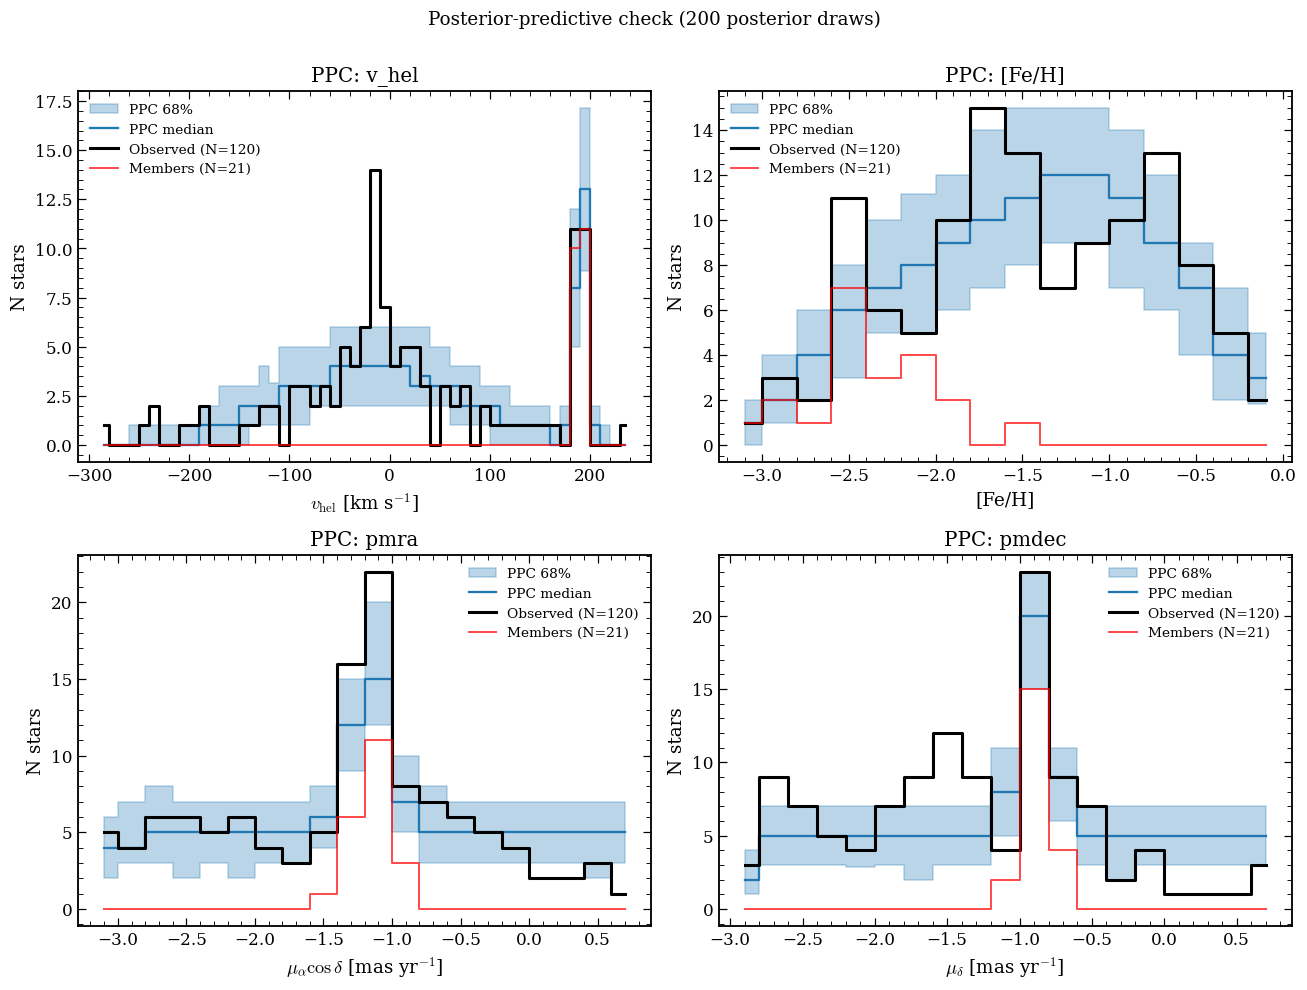

In [7]:
rng = np.random.default_rng(0)
N_DRAWS = 200; N_STARS = len(df_in)

def _sample_truncnorm(mu, sigma, low, high, size):
    a, b = (low - mu) / sigma, (high - mu) / sigma
    return stats.truncnorm.rvs(a, b, loc=mu, scale=sigma, size=size, random_state=rng)

post = samples.sample(n=N_DRAWS, replace=False, random_state=42).reset_index(drop=True)
mock_v   = np.empty((N_DRAWS, N_STARS))
mock_feh = np.empty((N_DRAWS, N_STARS))
mock_pmr = np.empty((N_DRAWS, N_STARS))
mock_pmd = np.empty((N_DRAWS, N_STARS))
v_err_per_star    = df_in["vel_calib_std"].values
feh_err_per_star  = df_in["feh_calib_std"].values
pmra_err_per_star = df_in["pmra_error"].values
pmdec_err_per_star= df_in["pmdec_error"].values

for i in range(N_DRAWS):
    f_m = post.loc[i, "f_mem"]
    v0  = post.loc[i, "vhel_0"];  sv  = 10 ** post.loc[i, "log_sig_vhel"]
    feh0= post.loc[i, "feh_0"];   sfeh= 10 ** post.loc[i, "log_sig_feh"]
    pra = post.loc[i, "pmr_0"];   pde = post.loc[i, "pmd_0"]
    bvm, bvs = post.loc[i, "bg_v_mean"],   10**post.loc[i, "log_bg_v_sigma"]
    bfm, bfs = post.loc[i, "bg_feh_mean"], 10**post.loc[i, "log_bg_feh_sigma"]
    is_gal = rng.random(N_STARS) < f_m; n_bg = N_STARS - int(is_gal.sum())
    mv = np.empty(N_STARS)
    mv[is_gal] = rng.normal(v0, np.sqrt(sv**2 + v_err_per_star[is_gal]**2))
    mv[~is_gal] = _sample_truncnorm(bvm, bvs, VHEL_BOX[0], VHEL_BOX[1], n_bg)
    mock_v[i] = mv
    mf = np.empty(N_STARS)
    mf[is_gal] = rng.normal(feh0, np.sqrt(sfeh**2 + feh_err_per_star[is_gal]**2))
    mf[~is_gal] = _sample_truncnorm(bfm, bfs, FEH_BOX[0], FEH_BOX[1], n_bg)
    mock_feh[i] = mf
    mr = np.empty(N_STARS); md_ = np.empty(N_STARS)
    mr[is_gal]  = rng.normal(pra, pmra_err_per_star[is_gal])
    md_[is_gal] = rng.normal(pde, pmdec_err_per_star[is_gal])
    mr[~is_gal]  = rng.uniform(PM_BOX[0], PM_BOX[1], n_bg)
    md_[~is_gal] = rng.uniform(PM_BOX[2], PM_BOX[3], n_bg)
    mock_pmr[i] = mr; mock_pmd[i] = md_

obs_v   = df_in["vel_calib"].values
obs_feh = df_in["feh50"].values
obs_pmr = df_in["pmra"].values
obs_pmd = df_in["pmdec"].values
mem_mask_ppc = (df_in["p_mem"] > 0.8).values

def bins_for(obs, bw):
    lo = np.floor(np.min(obs) / bw) * bw
    hi = np.ceil(np.max(obs)  / bw) * bw
    return np.arange(lo, hi + bw/2, bw)

configs = [
    ("v_hel",  obs_v,   mock_v,   bins_for(obs_v,   10.0), r"$v_{\rm hel}$ [km s$^{-1}$]"),
    ("[Fe/H]", obs_feh, mock_feh, bins_for(obs_feh, 0.2),  r"[Fe/H]"),
    ("pmra",   obs_pmr, mock_pmr, bins_for(obs_pmr, 0.2),  r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]"),
    ("pmdec",  obs_pmd, mock_pmd, bins_for(obs_pmd, 0.2),  r"$\mu_\delta$ [mas yr$^{-1}$]"),
]
fig, axs = plt.subplots(2, 2, figsize=(12, 9)); axs = axs.flatten()
for ax, (name, obs, mock, bins, xlabel) in zip(axs, configs):
    counts = np.array([np.histogram(mock[i], bins=bins)[0] for i in range(N_DRAWS)])
    q16, q50, q84 = np.percentile(counts, [16, 50, 84], axis=0)
    bc = 0.5 * (bins[:-1] + bins[1:])
    ax.fill_between(bc, q16, q84, color="tab:blue", alpha=0.3, step="mid", label="PPC 68%")
    ax.step(bc, q50, where="mid", color="tab:blue", lw=1.5, label="PPC median")
    obs_counts, _ = np.histogram(obs, bins=bins)
    ax.step(bc, obs_counts, where="mid", color="k", lw=2, label=f"Observed (N={len(obs)})")
    mem_counts, _ = np.histogram(obs[mem_mask_ppc], bins=bins)
    ax.step(bc, mem_counts, where="mid", color="red", lw=1.3, alpha=0.7,
            label=f"Members (N={mem_mask_ppc.sum()})")
    ax.set_xlabel(xlabel); ax.set_ylabel("N stars"); ax.set_title(f"PPC: {name}")
    ax.legend(fontsize=9)
fig.suptitle(f"Posterior-predictive check ({N_DRAWS} posterior draws)", fontsize=12, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(Path('/tmp') / 'fig_ppc.pdf', dpi=200, bbox_inches="tight")
plt.show(); plt.close(fig)

## 6 · Figure 1 — 4-panel membership diagnostic

| panel | content |
|:-:|:--|
| 1 | sky distribution with 1, 3 r_h ellipses, OLD/NEW centre markers |
| 2 | proper motion + Carlin+18 PM box (orange dashed) |
| 3 | CMD vs Dartmouth iso ([Fe/H] = -2.1, 12 Gyr) + M92 BHB ridgeline |
| 4 | RV vs [Fe/H] |

Members with p_mem > 0.8: 21



Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig1_members.pdf


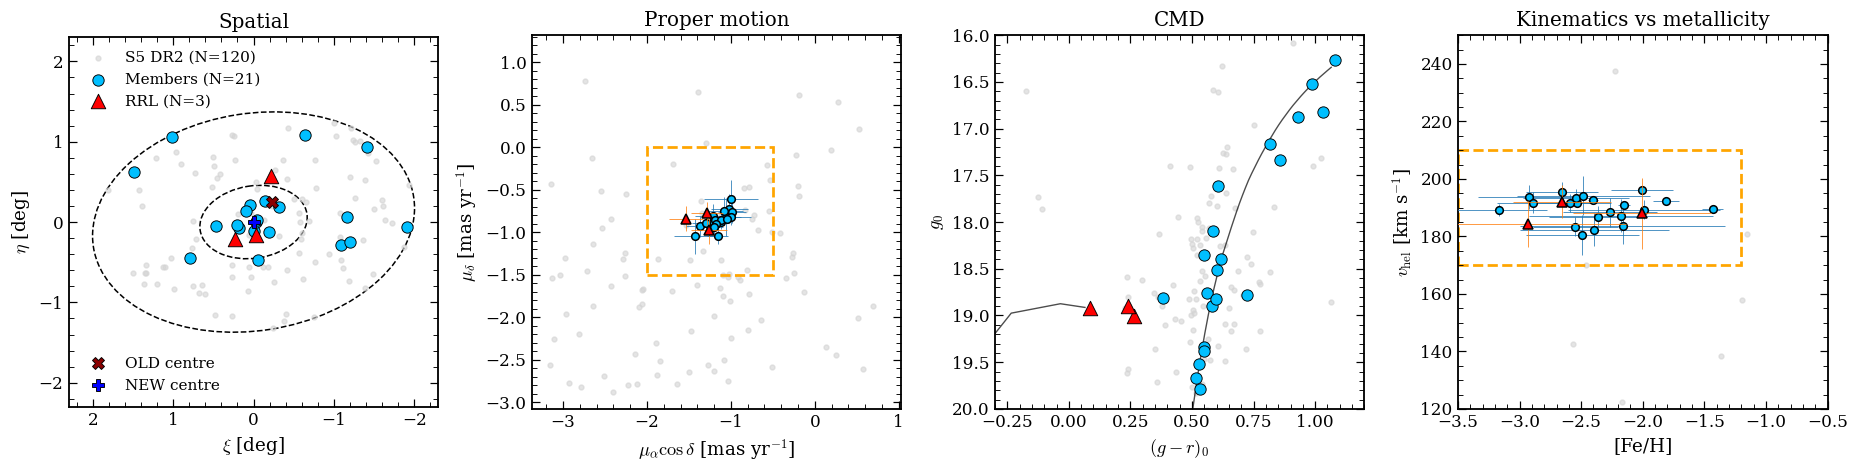

In [8]:
mem_mask = (df_in["p_mem"] > 0.8).values
mem_df   = df_in.loc[mem_mask].copy()
print(f"Members with p_mem > 0.8: {mem_mask.sum()}")

fig, axs = plt.subplots(1, 4, figsize=(17, 4.4))
rh = RHALF_MAJOR_DEG

# --- Panel 1: Spatial ---
ax = axs[0]
for n in (1, 3):
    ax.add_patch(Ellipse((0, 0), 2*n*rh, 2*n*rh*(1 - ELLIPTICITY),
                          angle=90 - PA_DEG, fill=False, ec="k",
                          ls="--", lw=1.0))
h_s5  = ax.scatter(df_in["ra_delta"], df_in["dec_delta"], s=10, c="lightgray",
                   alpha=0.6, zorder=1, label=f"S5 DR2 (N={len(df_in)})")
h_mem = ax.scatter(mem_df["ra_delta"], mem_df["dec_delta"],
                   marker="o", s=55, c="deepskyblue", ec="k", lw=0.6, zorder=3,
                   label=f"Members (N={mem_mask.sum()})")
h_rrl = None
if len(t_rrl):
    h_rrl = ax.scatter(t_rrl["ra_delta"], t_rrl["dec_delta"], marker="^", s=90,
                       c="red", ec="k", lw=0.6, zorder=4,
                       label=f"RRL (N={len(t_rrl)})")
# OLD (Grillmair+09) and NEW (this work, ellipse-centroid) centre markers
_cd = np.cos(np.radians(DEC_BOO3))
_old_dra  = (209.300 - RA_BOO3) * _cd
_old_ddec = 26.800  - DEC_BOO3
h_old, = ax.plot(_old_dra, _old_ddec, "X", c="darkred", ms=8, mec="black",
                 mew=0.6, zorder=11, label="OLD centre")
h_new, = ax.plot(0, 0, "P", c="blue", ms=8, mec="black", mew=0.6, zorder=12,
                 label="NEW centre")
ax.set_xlim(2.3, -2.3); ax.set_ylim(-2.3, 2.3); ax.set_aspect("equal")
ax.set_xlabel(r"$\xi$ [deg]")
ax.set_ylabel(r"$\eta$ [deg]")
ax.set_title("Spatial")
# Two separate legends so the bottom-left center markers don't sit on the members:
_top_handles = [h for h in (h_s5, h_mem, h_rrl) if h is not None]
leg1 = ax.legend(handles=_top_handles, loc="upper left", fontsize=10,
                 frameon=False)
ax.add_artist(leg1)
ax.legend(handles=[h_old, h_new], loc="lower left", fontsize=10,
          frameon=False)

# --- Panel 2: Proper motion ---
ax = axs[1]
ax.scatter(df_in["pmra"], df_in["pmdec"], s=10, c="lightgray", alpha=0.6, zorder=1, rasterized=True)
ax.errorbar(mem_df["pmra"], mem_df["pmdec"],
            xerr=mem_df["pmra_error"], yerr=mem_df["pmdec_error"],
            fmt="o", ms=5, mfc="deepskyblue", mec="k", lw=0.5, zorder=3)
if len(t_rrl):
    ax.errorbar(t_rrl["pmra"], t_rrl["pmdec"],
                xerr=t_rrl["pmra_error"], yerr=t_rrl["pmdec_error"],
                fmt="^", ms=7, mfc="red", mec="k", lw=0.5, zorder=4)
ax.add_patch(Rectangle((CARLIN_BOX[0], CARLIN_BOX[2]),
                        CARLIN_BOX[1]-CARLIN_BOX[0],
                        CARLIN_BOX[3]-CARLIN_BOX[2],
                        fill=False, ec="orange", lw=1.8, ls="--",
                        label="PM box: pmra (-2,-0.5), pmdec (-1.5,0)"))
ax.set_xlim(PM_BOX[0]-0.2, PM_BOX[1]+0.2)
ax.set_ylim(PM_BOX[2]-0.2, PM_BOX[3]+0.2)
ax.set_xlabel(r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("Proper motion")

# --- Panel 3: CMD ---
ax = axs[2]
try:
    iso = aio.read(str(ISO_FILE), header_start=8)
    ax.plot(iso["DECam_g"] - iso["DECam_r"], iso["DECam_g"] + DM_BOO3,
            "k-", lw=0.9, alpha=0.7)
except Exception as e:
    print(f"  (isochrone load failed: {e})")
_m92_r = np.array([16.8, 15.8, 15.38, 15.1, 15.05])
_m92_g = _m92_r + np.array([-0.36, -0.3, -0.2, -0.0, 0.1])
_des_g = _m92_g - 0.104*(_m92_g - _m92_r) + 0.01 - 0.023*3.184
_des_r = _m92_r - 0.102*(_m92_g - _m92_r) + 0.02 - 0.023*2.130
ax.plot(_des_g - _des_r, _des_g - 14.59 + DM_BOO3, "k-", lw=0.9, alpha=0.7, rasterized=True)
ax.scatter(df_in["decam_g0"] - df_in["decam_r0"], df_in["decam_g0"], s=10,
           c="lightgray", alpha=0.6)
ax.scatter(mem_df["decam_g0"] - mem_df["decam_r0"], mem_df["decam_g0"],
           marker="o", s=55, c="deepskyblue", ec="k", lw=0.6, zorder=3)
if len(t_rrl):
    ax.scatter(t_rrl["decam_g0"] - t_rrl["decam_r0"], t_rrl["decam_g0"],
               marker="^", s=90, c="red", ec="k", lw=0.6, zorder=4)
ax.set_xlim(-0.3, 1.2); ax.set_ylim(20, 16)
ax.set_xlabel(r"$(g-r)_0$"); ax.set_ylabel(r"$g_0$")
ax.set_title("CMD")

# --- Panel 4: RV vs [Fe/H] ---
ax = axs[3]
ax.scatter(df_in["feh50"], df_in["vel_calib"], s=10, c="lightgray", alpha=0.6, rasterized=True)
ax.errorbar(mem_df["feh50"], mem_df["vel_calib"],
            xerr=mem_df["feh_calib_std"], yerr=mem_df["vel_calib_std"],
            fmt="o", ms=5, mfc="deepskyblue", mec="k", lw=0.5, zorder=3)
if len(t_rrl):
    ax.errorbar(t_rrl["feh50"], t_rrl["vel_calib"],
                xerr=t_rrl["feh_calib_std"], yerr=t_rrl["vel_calib_std"],
                fmt="^", ms=7, mfc="red", mec="k", lw=0.5, zorder=4)
ax.add_patch(Rectangle((-3.5, 170), -1.2 - (-3.5), 210 - 170,
                       fill=False, ec="orange", lw=1.8, ls="--"))
ax.set_xlim(-3.5, -0.5); ax.set_ylim(120, 250)
ax.set_xlabel("[Fe/H]"); ax.set_ylabel(r"$v_{\rm hel}$ [km s$^{-1}$]")
ax.set_title("Kinematics vs metallicity")

fig.tight_layout()
out_pdf = FIG_DIR / "fig1_members.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"\nSaved {out_pdf}")
plt.show()

## 7 · Appendix Figure A3 — Tidal-tail candidates beyond 3 r_h

Six S5 candidates between ~1.2-2.2 a_h: 2 likely tidal-tail members and 4 likely
halo contaminants.  See Appendix A2 of the paper.

  Likely tail members: 2,  non-members: 4



Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/figA3_tidaltail_candidates.pdf


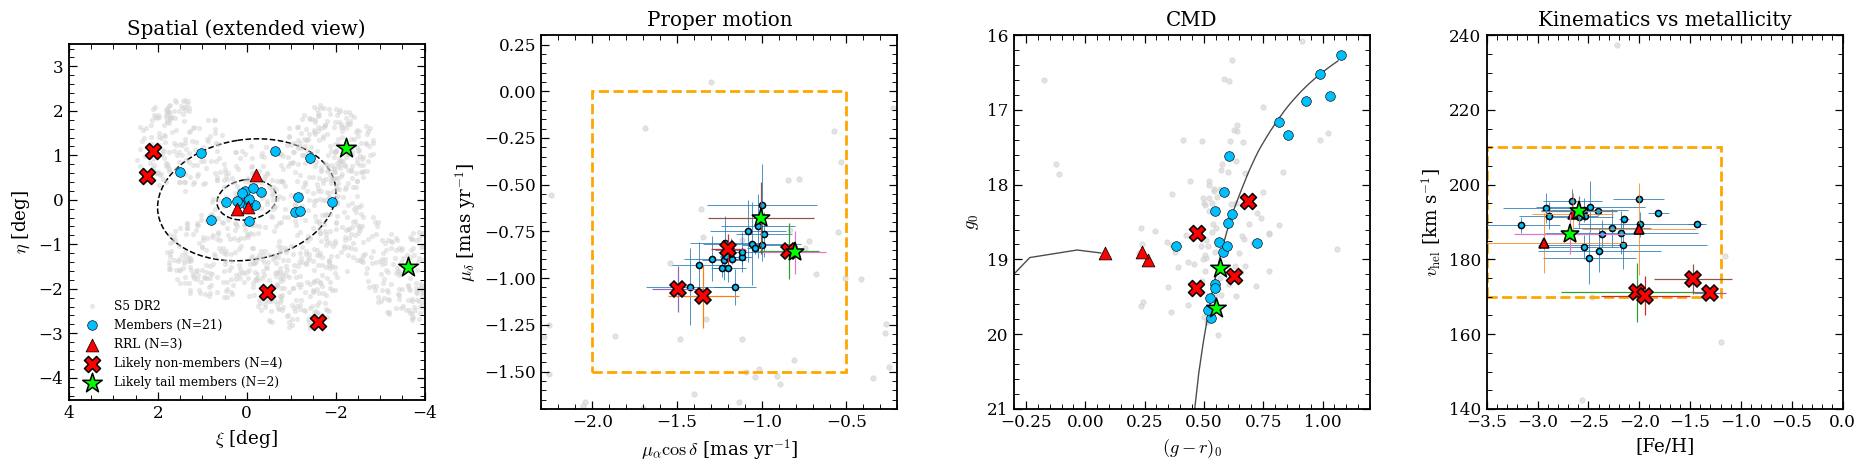


Auto-generated Table 6 (6 candidates) -> /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/paper/boo3_appendix_candidates.tex

Table 6 contents (matches boo3_appendix_candidates.tex):
  source_id              class                         v_hel          [Fe/H]   logg  r/r_h
  1451743686723428352    Likely member        186.77+/-5.32  -2.69+/-0.54   3.51   3.74
  1445105484053956352    Likely member        193.09+/-3.92  -2.59+/-0.37   3.22   5.83
  1251933905373373184    Likely non-member    171.16+/-7.93  -2.02+/-0.74   4.08   4.73
  1257953177484247040    Likely non-member    170.30+/-5.26  -1.94+/-0.44   3.24   3.14
  1260280877960110464    Likely non-member    170.89+/-1.27  -1.31+/-0.16   2.28   3.53
  1260200957212406528    Likely non-member    174.79+/-4.07  -1.47+/-0.38   3.44   3.43


In [9]:
LIKELY_MEMBERS    = [1451743686723428352, 1445105484053956352]
LIKELY_NONMEMBERS = [1251933905373373184, 1257953177484247040,
                     1260280877960110464, 1260200957212406528]

with fits.open(str(S5_DR2_FITS)) as h:
    t_a1 = atable.Table(h[1].data)
t_a1 = t_a1[t_a1["object_name"] == "Styx"]
t_a1["decam_g0"], t_a1["decam_r0"], *_ = deredden_mag_S5(t_a1)
add_delta_coordinates(t_a1, RA_BOO3, DEC_BOO3)
qc = ((t_a1["best_sn_1700d"] > 2) & (t_a1["vel_calib_std"] < 10)
       & (t_a1["good_star_pb"] > 0.5)
       & np.isfinite(t_a1["pmra"]) & np.isfinite(t_a1["pmdec"])
       & (np.abs(t_a1["vel_calib"]) < 600) & (t_a1["feh50"] < 0))
t_a1 = t_a1[qc]
cs_a1 = SkyCoord(ra=t_a1["ra"].data * u.deg, dec=t_a1["dec"].data * u.deg)
_, sep_a1, _ = cs_a1.match_to_catalog_sky(cr)
t_a1 = t_a1[sep_a1 >= 2 * u.arcsec]

def _grab(sid_list):
    return [t_a1[t_a1["source_id"] == sid][0]
            for sid in sid_list if (t_a1["source_id"] == sid).sum()]
mem_cand_rows = _grab(LIKELY_MEMBERS)
non_cand_rows = _grab(LIKELY_NONMEMBERS)
print(f"  Likely tail members: {len(mem_cand_rows)},  non-members: {len(non_cand_rows)}")

fig, axs = plt.subplots(1, 4, figsize=(17, 4.4))
rh = RHALF_MAJOR_DEG
mem_kw = dict(marker="*", s=180, c="lime", ec="k", lw=1.0, zorder=20)
non_kw = dict(marker="X", s=110, c="red",  ec="k", lw=1.0, zorder=20)

ax = axs[0]
for n in (1, 3):
    ax.add_patch(Ellipse((0, 0), 2*n*rh, 2*n*rh*(1 - ELLIPTICITY),
                          angle=90 - PA_DEG, fill=False, ec="k", ls="--", lw=1.0))
ax.scatter(t_a1["ra_delta"], t_a1["dec_delta"], s=6, c="lightgray",
           alpha=0.4, zorder=1, label="S5 DR2")
ax.scatter(mem_df["ra_delta"], mem_df["dec_delta"], marker="o", s=40,
           c="deepskyblue", ec="k", lw=0.4, zorder=3,
           label=f"Members (N={mem_mask.sum()})")
if len(t_rrl):
    ax.scatter(t_rrl["ra_delta"], t_rrl["dec_delta"], marker="^", s=70,
               c="red", ec="k", lw=0.5, zorder=4, label=f"RRL (N={len(t_rrl)})")
for r in non_cand_rows: ax.scatter(r["ra_delta"], r["dec_delta"], **non_kw, rasterized=True)
for r in mem_cand_rows: ax.scatter(r["ra_delta"], r["dec_delta"], **mem_kw, rasterized=True)
ax.scatter([], [], **non_kw, label=f"Likely non-members (N={len(non_cand_rows)})", rasterized=True)
ax.scatter([], [], **mem_kw, label=f"Likely tail members (N={len(mem_cand_rows)})", rasterized=True)
ax.set_xlim(4.0, -4.0); ax.set_ylim(-4.5, 3.5); ax.set_aspect("equal")
ax.set_xlabel(r"$\xi$ [deg]"); ax.set_ylabel(r"$\eta$ [deg]")
ax.set_title("Spatial (extended view)")
ax.legend(loc="lower left", fontsize=8)

ax = axs[1]
ax.scatter(df_in["pmra"], df_in["pmdec"], s=10, c="lightgray", alpha=0.6, zorder=1, rasterized=True)
ax.errorbar(mem_df["pmra"], mem_df["pmdec"],
            xerr=mem_df["pmra_error"], yerr=mem_df["pmdec_error"],
            fmt="o", ms=4, mfc="deepskyblue", mec="k", lw=0.5, zorder=3)
for r in non_cand_rows:
    ax.errorbar(r["pmra"], r["pmdec"], xerr=r["pmra_error"], yerr=r["pmdec_error"],
                fmt="X", ms=10, mfc="red", mec="k", lw=0.8, zorder=20)
for r in mem_cand_rows:
    ax.errorbar(r["pmra"], r["pmdec"], xerr=r["pmra_error"], yerr=r["pmdec_error"],
                fmt="*", ms=13, mfc="lime", mec="k", lw=0.8, zorder=20)
ax.add_patch(Rectangle((CARLIN_BOX[0], CARLIN_BOX[2]),
                       CARLIN_BOX[1]-CARLIN_BOX[0],
                       CARLIN_BOX[3]-CARLIN_BOX[2],
                       fill=False, ec="orange", lw=1.8, ls="--"))
ax.set_xlim(-2.3, -0.2); ax.set_ylim(-1.7, 0.3)
ax.set_xlabel(r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]")
ax.set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
ax.set_title("Proper motion")

ax = axs[2]
try:
    iso = aio.read(str(ISO_FILE), header_start=8)
    ax.plot(iso["DECam_g"] - iso["DECam_r"], iso["DECam_g"] + DM_BOO3,
            "k-", lw=0.9, alpha=0.7)
except Exception as e:
    print(f"  (isochrone load failed: {e})")
_m92_r = np.array([16.8, 15.8, 15.38, 15.1, 15.05])
_m92_g = _m92_r + np.array([-0.36, -0.3, -0.2, -0.0, 0.1])
_des_g = _m92_g - 0.104*(_m92_g - _m92_r) + 0.01 - 0.023*3.184
_des_r = _m92_r - 0.102*(_m92_g - _m92_r) + 0.02 - 0.023*2.130
ax.plot(_des_g - _des_r, _des_g - 14.59 + DM_BOO3, "k-", lw=0.9, alpha=0.7, rasterized=True)
ax.scatter(df_in["decam_g0"] - df_in["decam_r0"], df_in["decam_g0"], s=10,
           c="lightgray", alpha=0.6)
ax.scatter(mem_df["decam_g0"] - mem_df["decam_r0"], mem_df["decam_g0"],
           marker="o", s=40, c="deepskyblue", ec="k", lw=0.4, zorder=3)
if len(t_rrl):
    ax.scatter(t_rrl["decam_g0"] - t_rrl["decam_r0"], t_rrl["decam_g0"],
               marker="^", s=70, c="red", ec="k", lw=0.5, zorder=4)
for r in non_cand_rows: ax.scatter(r["decam_g0"] - r["decam_r0"], r["decam_g0"], **non_kw, rasterized=True)
for r in mem_cand_rows: ax.scatter(r["decam_g0"] - r["decam_r0"], r["decam_g0"], **mem_kw, rasterized=True)
ax.set_xlim(-0.3, 1.2); ax.set_ylim(21, 16)
ax.set_xlabel(r"$(g-r)_0$"); ax.set_ylabel(r"$g_0$"); ax.set_title("CMD")

ax = axs[3]
ax.scatter(df_in["feh50"], df_in["vel_calib"], s=10, c="lightgray", alpha=0.6, rasterized=True)
ax.errorbar(mem_df["feh50"], mem_df["vel_calib"],
            xerr=mem_df["feh_calib_std"], yerr=mem_df["vel_calib_std"],
            fmt="o", ms=4, mfc="deepskyblue", mec="k", lw=0.5, zorder=3)
if len(t_rrl):
    ax.errorbar(t_rrl["feh50"], t_rrl["vel_calib"],
                xerr=t_rrl["feh_calib_std"], yerr=t_rrl["vel_calib_std"],
                fmt="^", ms=7, mfc="red", mec="k", lw=0.5, zorder=4)
for r in non_cand_rows:
    ax.errorbar(r["feh50"], r["vel_calib"], xerr=r["feh_calib_std"], yerr=r["vel_calib_std"],
                fmt="X", ms=10, mfc="red", mec="k", lw=0.8, zorder=20)
for r in mem_cand_rows:
    ax.errorbar(r["feh50"], r["vel_calib"], xerr=r["feh_calib_std"], yerr=r["vel_calib_std"],
                fmt="*", ms=13, mfc="lime", mec="k", lw=0.8, zorder=20)
ax.add_patch(Rectangle((-3.5, 170), -1.2 - (-3.5), 210 - 170,
                       fill=False, ec="orange", lw=1.8, ls="--"))
ax.set_xlim(-3.5, 0); ax.set_ylim(140, 240)
ax.set_xlabel("[Fe/H]"); ax.set_ylabel(r"$v_{\rm hel}$ [km s$^{-1}$]")
ax.set_title("Kinematics vs metallicity")
fig.tight_layout()
out_pdf = FIG_DIR / "figA3_tidaltail_candidates.pdf"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
print(f"\nSaved {out_pdf}")
plt.show()


# ---- Auto-generate Table 6: 6 outside-3 r_h box-cut candidates (boo3_appendix_candidates.tex) ----
# Mirrors the Table-3 / Table-4 writers in cell 8 / cell 12. Reads source_id as
# int64 throughout so the 19-digit Gaia IDs are preserved bit-for-bit.
def _t6_make_row(r, cls):
    """Build one \\hline-terminated TeX row from an astropy Table row."""
    sid = int(r["source_id"])
    return (
        f"{sid} & {float(r['ra']):.4f} & {float(r['dec']):.4f} & "
        f"{float(r['decam_g0']):.2f} & {float(r['decam_r0']):.2f} & "
        f"{float(r['vel_calib']):.2f}$\\pm${float(r['vel_calib_std']):.2f} & "
        f"{float(r['feh50']):.2f}$\\pm${float(r['feh_calib_std']):.2f} & "
        f"{float(r['pmra']):+.3f} & {float(r['pmdec']):+.3f} & "
        f"{float(r['logg50']):.2f} & "
        f"{float(np.hypot(r['ra_delta'], r['dec_delta']) / RHALF_MAJOR_DEG):.2f} & "
        f"{cls} \\\\"
    )

_t6_lines = []
for r in mem_cand_rows: _t6_lines.append(_t6_make_row(r, "Likely member"))
for r in non_cand_rows: _t6_lines.append(_t6_make_row(r, "Likely non-member"))

_t6_tex = (
    "\\centerwidetable\n"
    "\\setlength{\\tabcolsep}{3pt}\n"
    "\\begin{deluxetable*}{rrrrrrrrrrrl}\n"
    "\\tabletypesize{\\footnotesize}\n"
    "\\tablecaption{Six \\SSSSS\\ DR2 stars beyond 3$r_h$ that pass the box "
    "selection of Section~\\ref{section:membership} (RV $\\in [170, 210]$ "
    "\\vlosUnits, $\\mu_\\alpha\\cos\\delta \\in [-2, -0.5]$ "
    "\\pmUnits, $\\mu_\\delta \\in [-1.5, 0]$ \\pmUnits, [Fe/H] $< -1.2$). "
    "Two are kinematic and chemical analogues of the 21 GMM members and are "
    "likely tidal-tail members; four cluster at $v_{\\rm hel} \\approx 170$ "
    "\\vlosUnits\\ and are likely halo contaminants (one with "
    "$\\log g \\approx 4$ is a foreground main-sequence star).\n"
    "\\label{tab:appendix_candidates}}\n"
    "\\tablehead{\n"
    "\\colhead{Gaia Source ID} & \\colhead{R.A.} & \\colhead{Decl.} & "
    "\\colhead{$g_0$} & \\colhead{$r_0$} & "
    "\\colhead{$v_\\mathrm{helio}$} & \\colhead{[Fe/H]} & "
    "\\colhead{$\\mu_\\alpha\\cos\\delta$} & \\colhead{$\\mu_\\delta$} & "
    "\\colhead{$\\log g$} & \\colhead{$r/r_h$} & \\colhead{Class}\\\\\n"
    " & \\colhead{(deg)} & \\colhead{(deg)} & "
    "\\colhead{(mag)} & \\colhead{(mag)} & "
    "\\colhead{(km/s)} & \\colhead{(dex)} & "
    "\\colhead{(\\pmUnits)} & \\colhead{(\\pmUnits)} & & &\n"
    "}\n"
    "\\startdata\n"
    + "\n".join(_t6_lines) + "\n"
    + "\\enddata\n"
    "\\end{deluxetable*}\n"
)
_t6_tex_path = PROJ / "paper" / "boo3_appendix_candidates.tex"
_t6_tex_path.write_text(_t6_tex)
print(f"\nAuto-generated Table 6 (6 candidates) -> {_t6_tex_path}")

print("\nTable 6 contents (matches boo3_appendix_candidates.tex):")
print(f"  {'source_id':<22s} {'class':<20s} {'v_hel':>14s}  {'[Fe/H]':>14s}  {'logg':>5s}  {'r/r_h':>5s}")
for r in mem_cand_rows + non_cand_rows:
    cls = "Likely member" if any(r['source_id']==m['source_id'] for m in mem_cand_rows) else "Likely non-member"
    print(f"  {int(r['source_id']):<22d} {cls:<20s} "
          f"{float(r['vel_calib']):>6.2f}+/-{float(r['vel_calib_std']):>4.2f}  "
          f"{float(r['feh50']):>+5.2f}+/-{float(r['feh_calib_std']):>4.2f}  "
          f"{float(r['logg50']):>5.2f}  {float(np.hypot(r['ra_delta'], r['dec_delta'])/RHALF_MAJOR_DEG):>5.2f}")


## 8 · Figure 2 — 7-parameter GMM corner plot

/tmp/claude-501/ipykernel_6855/1103749701.py:27: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x34f09dbb0>' will be ignored
  coll.set_rasterized(True)
/tmp/claude-501/ipykernel_6855/1103749701.py:27: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x34f7ba450>' will be ignored
  coll.set_rasterized(True)
/tmp/claude-501/ipykernel_6855/1103749701.py:27: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x34f86cc80>' will be ignored
  coll.set_rasterized(True)
/tmp/claude-501/ipykernel_6855/1103749701.py:27: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x34f8ba540>' will be ignored
  coll.set_rasterized(True)
/tmp/claude-501/ipykernel_6855/1103749701.py:27: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x34b06aa20>' will be ignored
  coll.set_rasterized(True)
/tmp/claude-501/ipykernel_6855/1103749701.py:27: UserWarning: Rasterization of '<matp

Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig2_corner.pdf


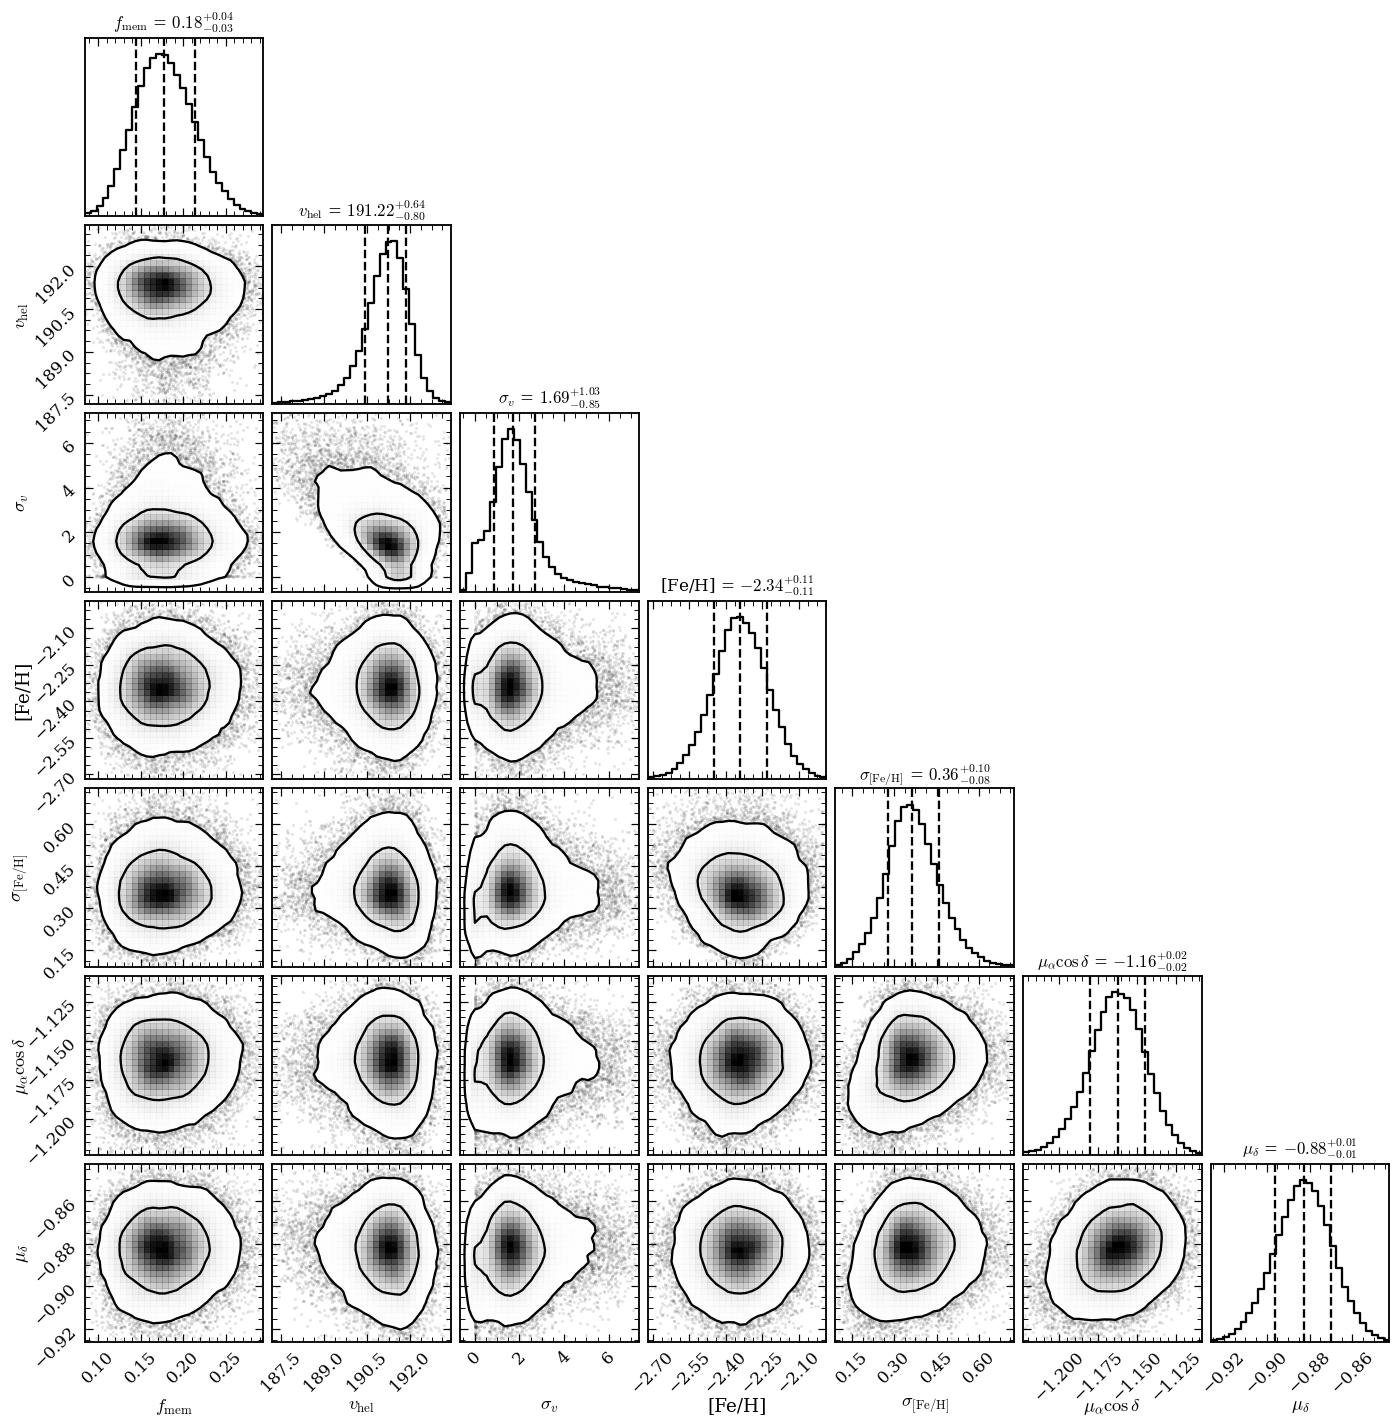

In [10]:
arr = np.column_stack([
    samples["f_mem"].values,
    samples["vhel_0"].values,
    10 ** samples["log_sig_vhel"].values,
    samples["feh_0"].values,
    10 ** samples["log_sig_feh"].values,
    samples["pmr_0"].values,
    samples["pmd_0"].values,
])
labels = [r"$f_{\rm mem}$", r"$v_{\rm hel}$", r"$\sigma_v$",
          r"[Fe/H]", r"$\sigma_{\rm [Fe/H]}$",
          r"$\mu_{\alpha}\cos\delta$", r"$\mu_{\delta}$"]

def _rng99(x, pad=0.1):
    lo, hi = np.percentile(x, [0.5, 99.5]); span = hi - lo
    return (lo - pad * span, hi + pad * span)
ranges = [_rng99(arr[:, i]) for i in range(arr.shape[1])]
fig = corner.corner(arr, labels=labels, quantiles=[0.16, 0.50, 0.84],
                     levels=(0.68, 0.95), show_titles=True,
                     title_kwargs={"fontsize": 11},
                     label_kwargs={"fontsize": 12},
                     range=ranges, bins=30, smooth=0.8, smooth1d=0.8)
fig.set_size_inches(13, 13)
# Rasterize the corner panels (scatter densities + hist patches) to keep the PDF small
for ax in fig.get_axes():
    for coll in ax.collections:
        coll.set_rasterized(True)
    for patch in ax.patches:
        patch.set_rasterized(True)
    for image in ax.get_images():
        image.set_rasterized(True)
fig.savefig(FIG_DIR / "fig2_corner.pdf", dpi=110, bbox_inches="tight")
print(f"Saved {FIG_DIR / 'fig2_corner.pdf'}")
plt.show()

## 9 · Orbit plot helpers (used by Figs 3 & A1)

Loads pre-computed trajectories from `01_compute_orbits.py`.

In [11]:
def _plot_orbit_row(axs_row, traj, label_prefix, xyz_lim=125, r_lim=160):
    """traj is a dict from a saved npz with keys fid_x/y/z/r, mc_x/y/z/r, ts."""
    plane_specs = [("XY", traj["fid_x"], traj["fid_y"], traj["mc_x"], traj["mc_y"]),
                   ("XZ", traj["fid_x"], traj["fid_z"], traj["mc_x"], traj["mc_z"]),
                   ("YZ", traj["fid_y"], traj["fid_z"], traj["mc_y"], traj["mc_z"]),
                   ("RT", traj["ts"],   traj["fid_r"], None,         traj["mc_r"])]
    for ax, (plane, xb, yb, xb_err, yb_err) in zip(axs_row, plane_specs):
        ax.plot(xb, yb, c="k", ls="--", zorder=2)
        if plane == "RT":
            for y in yb_err[::10]:
                ax.plot(xb, y, c="deepskyblue", alpha=0.1, zorder=1, rasterized=True)
            ax.set_xlabel("t [Gyr]"); ax.set_ylabel("R [kpc]")
            ax.set_ylim(0, r_lim)
        else:
            for x, y in zip(xb_err[::10], yb_err[::10]):
                ax.plot(x, y, c="deepskyblue", alpha=0.1, zorder=1, rasterized=True)
            ax.set_xlabel(plane[0] + " [kpc]"); ax.set_ylabel(plane[1] + " [kpc]")
            ax.set_xlim(-xyz_lim, xyz_lim); ax.set_ylim(-xyz_lim, xyz_lim)
        ax.plot(xb[0], yb[0], "ok", zorder=2)
        ax.set_aspect("auto")

def _load_traj(npz_path, prefix):
    """Pull (ts, fid_x/y/z/r, mc_x/y/z/r) out of the saved npz under given prefix."""
    z = np.load(npz_path)
    return dict(ts=z[f"{prefix}_ts"],
                fid_x=z[f"{prefix}_fid_x"], fid_y=z[f"{prefix}_fid_y"],
                fid_z=z[f"{prefix}_fid_z"], fid_r=z[f"{prefix}_fid_r"],
                mc_x=z[f"{prefix}_mc_x"],   mc_y=z[f"{prefix}_mc_y"],
                mc_z=z[f"{prefix}_mc_z"],   mc_r=z[f"{prefix}_mc_r"])

## 10 · Figure 3 — McMillan17 orbital trajectories

Top row: McMillan17 alone.  Bottom: + LMC.  Black dashed = fiducial; cyan = 100/1000 MC.

Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig3_orbit_McMillan17.pdf


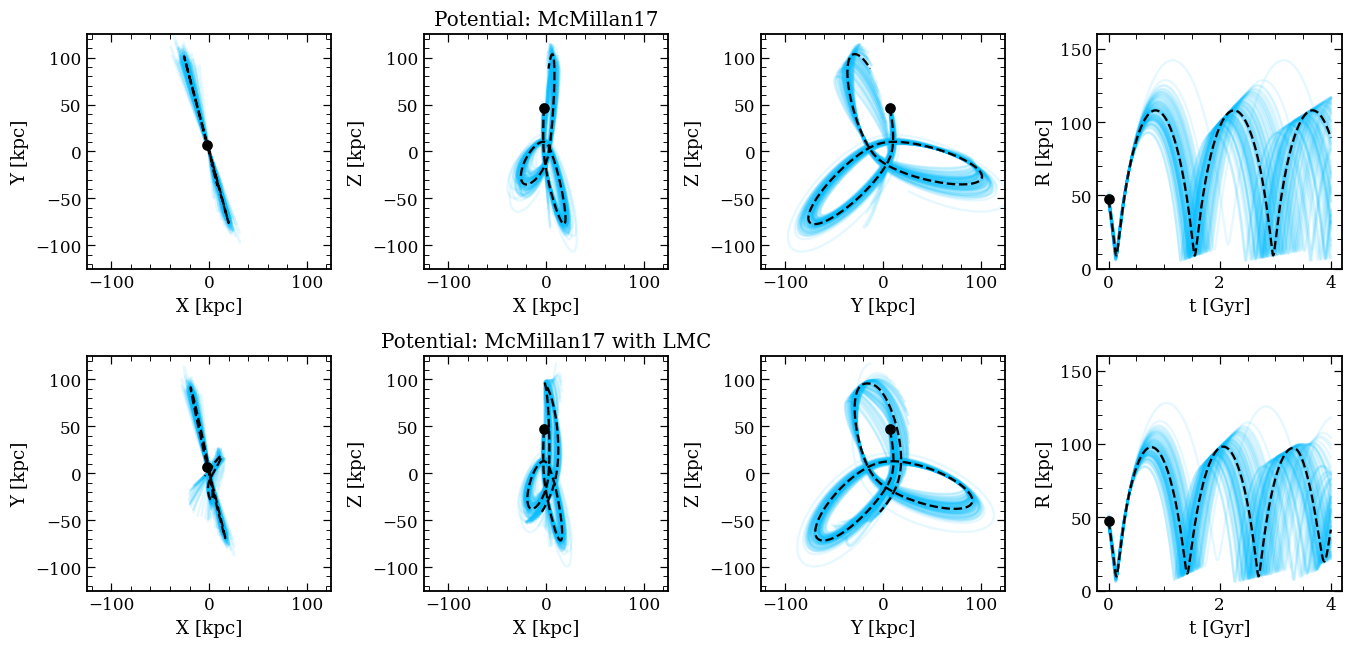

In [12]:
MCM_TRAJ = OUT_DIR / "orbit_McMillan17_trajectories.npz"
assert MCM_TRAJ.exists(), f"MISSING {MCM_TRAJ} — run 01_compute_orbits.py first"
traj_no  = _load_traj(MCM_TRAJ, "no_lmc")
traj_lmc = _load_traj(MCM_TRAJ, "lmc")

fig, axes = plt.subplots(2, 4, figsize=(12.4, 6))
_plot_orbit_row(axes[0], traj_no,  "no LMC",  xyz_lim=125, r_lim=160)
_plot_orbit_row(axes[1], traj_lmc, "with LMC",xyz_lim=125, r_lim=160)
axes[0, 1].set_title("Potential: McMillan17")
axes[1, 1].set_title("Potential: McMillan17 with LMC")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_orbit_McMillan17.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIG_DIR / 'fig3_orbit_McMillan17.pdf'}")
plt.show()

## 11 · Figure 4 — peri / apo / eccentricity corners (McMillan17)

Summary  (median +sig68 / -sig68):
  No LMC     peri =   9.03  +2.05 / -1.75 kpc
             apo  = 107.68  +8.86 / -7.45 kpc
             e    =  0.846  +0.019 / -0.019
  With LMC   peri =   9.47  +2.11 / -1.83 kpc
             apo  =  97.47  +7.65 / -6.45 kpc
             e    =  0.823  +0.021 / -0.021


Saved /tmp/fig4_orbit_params_McMillan17_No_LMC.pdf (intermediate)


Saved /tmp/fig4_orbit_params_McMillan17_With_LMC.pdf (intermediate)


Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/fig4_orbit_params_McMillan17.pdf


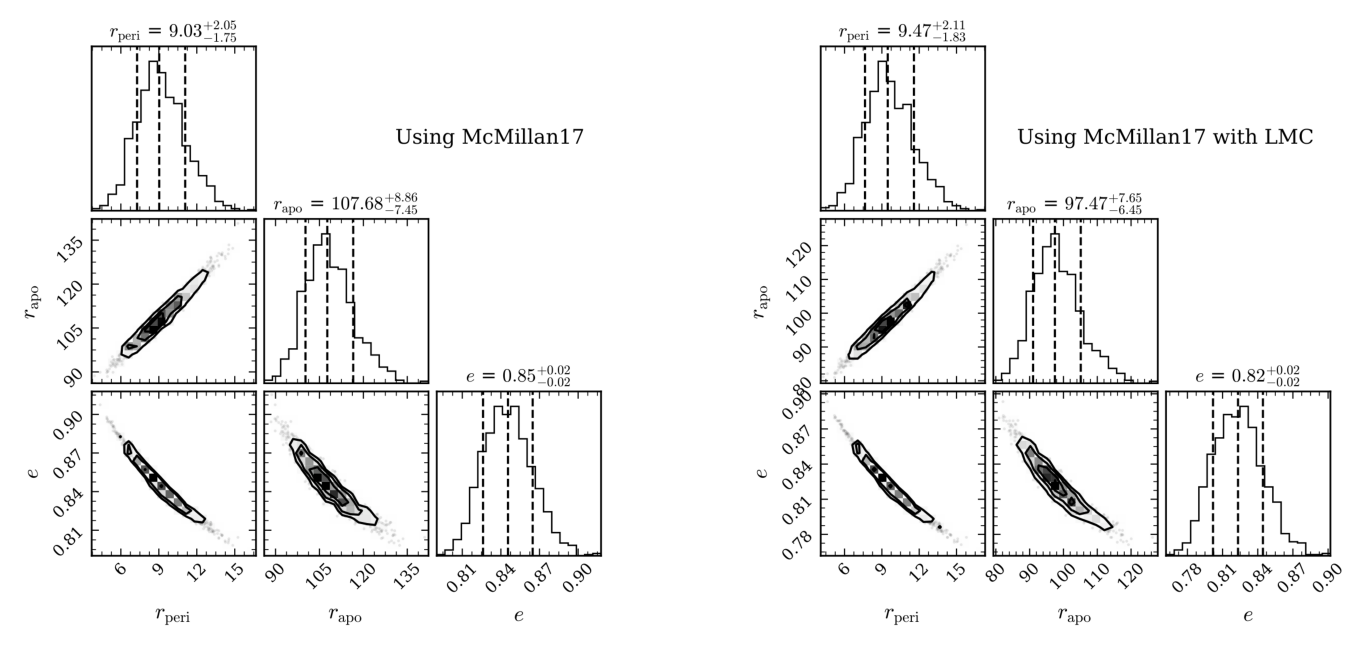

In [13]:
MCM_SAMP = OUT_DIR / "orbit_McMillan17_samples.npz"
assert MCM_SAMP.exists(), f"MISSING {MCM_SAMP} — run 01_compute_orbits.py first"
_z = np.load(MCM_SAMP)
peri_no, apo_no, e_no    = _z["peri_no"],  _z["apo_no"],  _z["e_no"]
peri_lmc, apo_lmc, e_lmc = _z["peri_lmc"], _z["apo_lmc"], _z["e_lmc"]

def _q(x):
    x = x[np.isfinite(x)]; lo, m, hi = np.percentile(x, [16, 50, 84])
    return m, m - lo, hi - m
print("Summary  (median +sig68 / -sig68):")
for lab, (p, a, e) in [("No LMC", (peri_no, apo_no, e_no)),
                        ("With LMC", (peri_lmc, apo_lmc, e_lmc))]:
    pm, pl, ph = _q(p); am, al, ah = _q(a); em, el, eh = _q(e)
    print(f"  {lab:<10} peri = {pm:6.2f}  +{ph:.2f} / -{pl:.2f} kpc")
    print(f"  {' ':<10} apo  = {am:6.2f}  +{ah:.2f} / -{al:.2f} kpc")
    print(f"  {' ':<10} e    = {em:6.3f}  +{eh:.3f} / -{el:.3f}")

for lab, p, a, e in [("No_LMC", peri_no, apo_no, e_no),
                     ("With_LMC", peri_lmc, apo_lmc, e_lmc)]:
    good = np.isfinite(p) & np.isfinite(a) & np.isfinite(e)
    data = np.vstack([p[good], a[good], e[good]]).T
    sub = corner.corner(data,
        labels=[r"$r_\mathrm{peri}$", r"$r_\mathrm{apo}$", r"$e$"],
        quantiles=[0.16, 0.50, 0.84], show_titles=True,
        title_kwargs={"fontsize": 13}, label_kwargs=dict(fontsize=15))
    sub.set_size_inches(6, 6)
    title = "Using McMillan17" if lab == "No_LMC" else "Using McMillan17 with LMC"
    sub.get_axes()[0].text(3, 0.5, title, fontsize=14, ha="right", va="top",
                            transform=sub.get_axes()[0].transAxes)
    sub.savefig(Path('/tmp') / f'fig4_orbit_params_McMillan17_{lab}.pdf',
                dpi=300, bbox_inches="tight")
    plt.close(sub)
    print(f"Saved /tmp/fig4_orbit_params_McMillan17_{lab}.pdf (intermediate)")

import fitz; from PIL import Image; from io import BytesIO
def _page_to_pil(pdf_path):
    doc = fitz.open(pdf_path)
    pix = doc[0].get_pixmap(matrix=fitz.Matrix(200/72, 200/72), alpha=False)
    img = Image.open(BytesIO(pix.tobytes("png"))); doc.close(); return img
im_no  = _page_to_pil(Path('/tmp') / 'fig4_orbit_params_McMillan17_No_LMC.pdf')
im_lmc = _page_to_pil(Path('/tmp') / 'fig4_orbit_params_McMillan17_With_LMC.pdf')
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(im_no);  axs[0].axis("off")
axs[1].imshow(im_lmc); axs[1].axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_orbit_params_McMillan17.pdf", dpi=200, bbox_inches="tight")
print(f"Saved {FIG_DIR / 'fig4_orbit_params_McMillan17.pdf'}")
plt.show()

## 12 · Appendix Figure A1 — MWPotential2014 orbital trajectories

Same 6D and same 1000-MC + LMC integration as Fig 3, but in `MWPotential2014`
(Bovy 2015) instead of McMillan17.  Wider plot ranges than Fig 3 because the
lighter MWP14 halo lets the orbit reach larger apo + makes some MC realisations
swing ~250 kpc in z.

Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/figA1_orbit_MWPotential2014.pdf


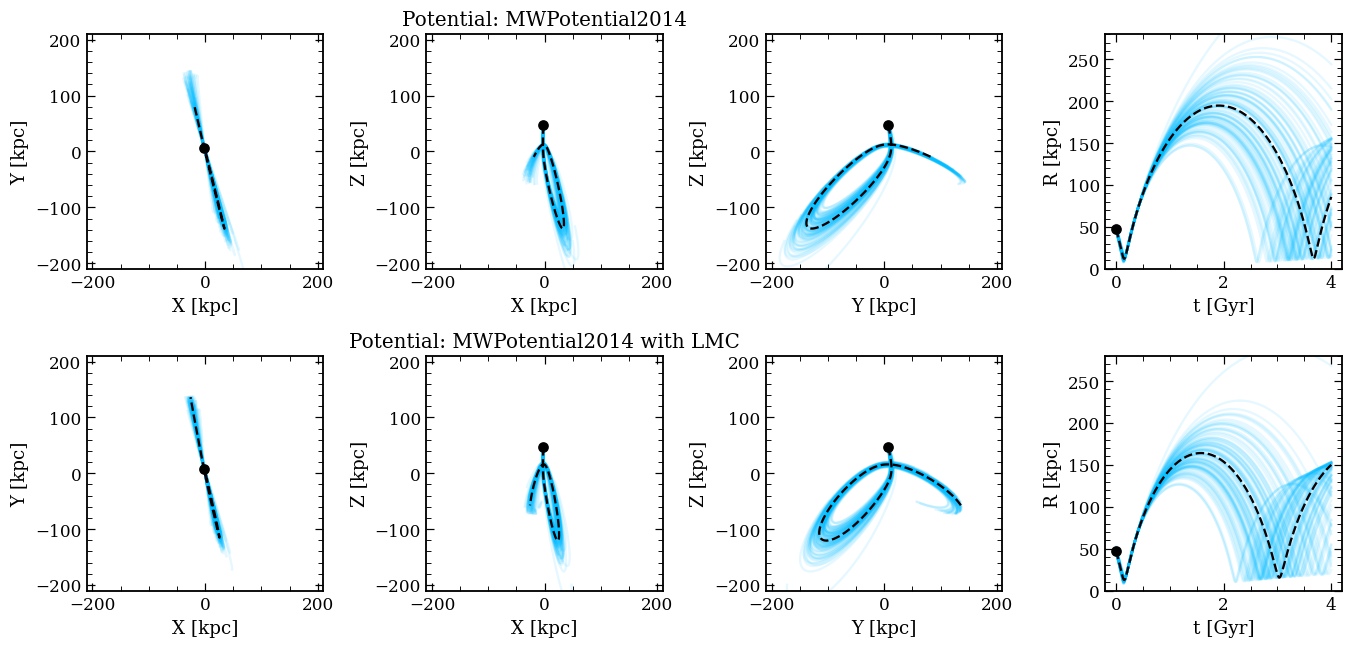

In [14]:
MWP_TRAJ = OUT_DIR / "orbit_MWPotential2014_trajectories.npz"
assert MWP_TRAJ.exists(), f"MISSING {MWP_TRAJ} — run 01_compute_orbits.py first"
traj_no_v2  = _load_traj(MWP_TRAJ, "no_lmc")
traj_lmc_v2 = _load_traj(MWP_TRAJ, "lmc")

fig, axes = plt.subplots(2, 4, figsize=(12.4, 6))
_plot_orbit_row(axes[0], traj_no_v2,  "no LMC (MWP14)",  xyz_lim=210, r_lim=280)
_plot_orbit_row(axes[1], traj_lmc_v2, "with LMC (MWP14)",xyz_lim=210, r_lim=280)
axes[0, 1].set_title("Potential: MWPotential2014")
axes[1, 1].set_title("Potential: MWPotential2014 with LMC")
fig.tight_layout()
fig.savefig(FIG_DIR / "figA1_orbit_MWPotential2014.pdf", dpi=300, bbox_inches="tight")
print(f"Saved {FIG_DIR / 'figA1_orbit_MWPotential2014.pdf'}")
plt.show()

## 13 · Appendix Figure A2 — peri / apo / e corners (MWPotential2014)

Summary (MWPotential2014, median +sig68 / -sig68):
  No LMC     peri =  11.89  +2.41 / -2.16 kpc
             apo  = 193.85  +32.09 / -24.29 kpc
             e    =  0.885  +0.007 / -0.005
  With LMC   peri =  12.43  +2.47 / -2.22 kpc
             apo  = 163.38  +24.83 / -19.28 kpc
             e    =  0.859  +0.009 / -0.006


Saved /tmp/figA2_orbit_params_MWPotential2014_No_LMC.pdf (intermediate)


Saved /tmp/figA2_orbit_params_MWPotential2014_With_LMC.pdf (intermediate)
Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/figA2_orbit_params_MWPotential2014.pdf


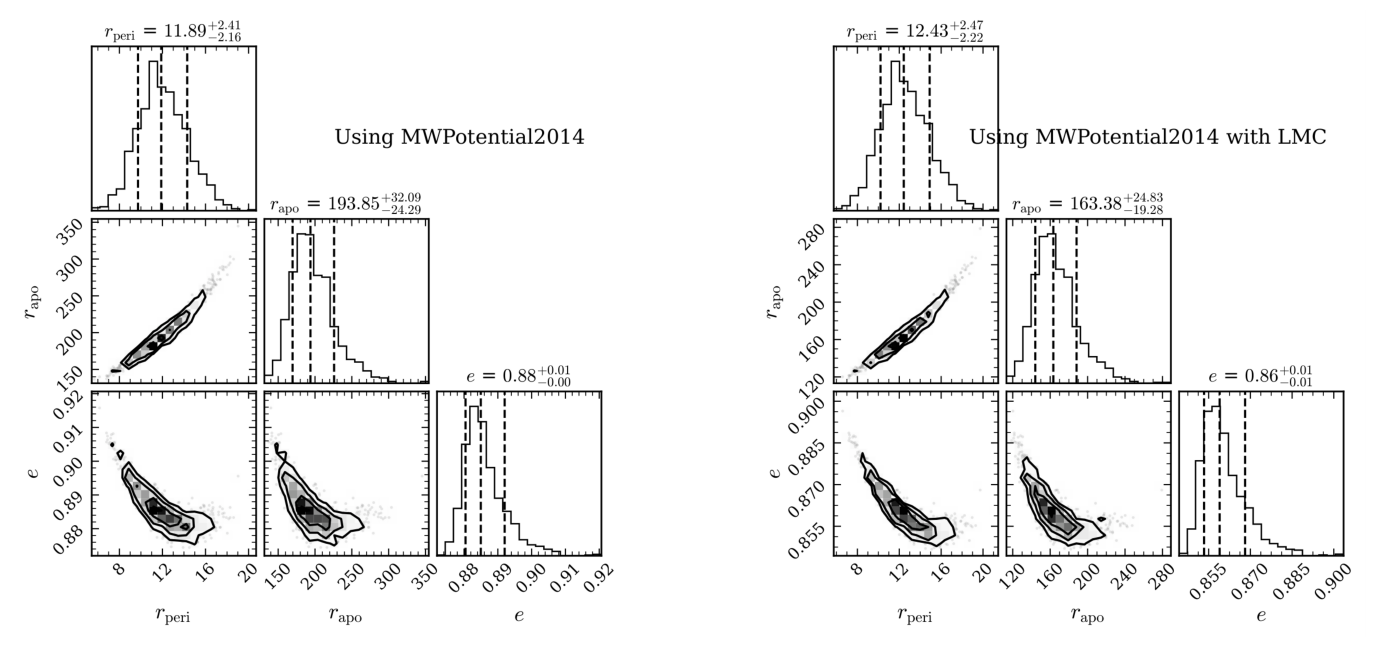

In [15]:
MWP_SAMP = OUT_DIR / "orbit_MWPotential2014_samples.npz"
assert MWP_SAMP.exists(), f"MISSING {MWP_SAMP} — run 01_compute_orbits.py first"
_z = np.load(MWP_SAMP)
peri_no_v2, apo_no_v2, e_no_v2    = _z["peri_no"],  _z["apo_no"],  _z["e_no"]
peri_lmc_v2, apo_lmc_v2, e_lmc_v2 = _z["peri_lmc"], _z["apo_lmc"], _z["e_lmc"]

print("Summary (MWPotential2014, median +sig68 / -sig68):")
for lab, (p, a, e) in [("No LMC", (peri_no_v2, apo_no_v2, e_no_v2)),
                        ("With LMC", (peri_lmc_v2, apo_lmc_v2, e_lmc_v2))]:
    pm, pl, ph = _q(p); am, al, ah = _q(a); em, el, eh = _q(e)
    print(f"  {lab:<10} peri = {pm:6.2f}  +{ph:.2f} / -{pl:.2f} kpc")
    print(f"  {' ':<10} apo  = {am:6.2f}  +{ah:.2f} / -{al:.2f} kpc")
    print(f"  {' ':<10} e    = {em:6.3f}  +{eh:.3f} / -{el:.3f}")

for lab, p, a, e in [("No_LMC", peri_no_v2, apo_no_v2, e_no_v2),
                     ("With_LMC", peri_lmc_v2, apo_lmc_v2, e_lmc_v2)]:
    good = np.isfinite(p) & np.isfinite(a) & np.isfinite(e)
    data = np.vstack([p[good], a[good], e[good]]).T
    sub = corner.corner(data,
        labels=[r"$r_\mathrm{peri}$", r"$r_\mathrm{apo}$", r"$e$"],
        quantiles=[0.16, 0.50, 0.84], show_titles=True,
        title_kwargs={"fontsize": 13}, label_kwargs=dict(fontsize=15))
    sub.set_size_inches(6, 6)
    title = "Using MWPotential2014" if lab == "No_LMC" else "Using MWPotential2014 with LMC"
    sub.get_axes()[0].text(3, 0.5, title, fontsize=14, ha="right", va="top",
                            transform=sub.get_axes()[0].transAxes)
    sub.savefig(Path('/tmp') / f'figA2_orbit_params_MWPotential2014_{lab}.pdf',
                dpi=300, bbox_inches="tight")
    plt.close(sub)
    print(f"Saved /tmp/figA2_orbit_params_MWPotential2014_{lab}.pdf (intermediate)")

im_no  = _page_to_pil(Path('/tmp') / 'figA2_orbit_params_MWPotential2014_No_LMC.pdf')
im_lmc = _page_to_pil(Path('/tmp') / 'figA2_orbit_params_MWPotential2014_With_LMC.pdf')
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
axs[0].imshow(im_no);  axs[0].axis("off")
axs[1].imshow(im_lmc); axs[1].axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "figA2_orbit_params_MWPotential2014.pdf", dpi=200, bbox_inches="tight")
print(f"Saved {FIG_DIR / 'figA2_orbit_params_MWPotential2014.pdf'}")
plt.show()

## 14 · Appendix Figure A4 — 6×5 per-component 6D-uncertainty study

Each row varies ONE 6D parameter at a time (others held at the fiducial); columns
show RA vs (Dec, μ_α cos δ, μ_δ, v_los, distance) for ±0.5 Gyr around the present.

Saved /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/figures/figA4_orbit_per_component.pdf


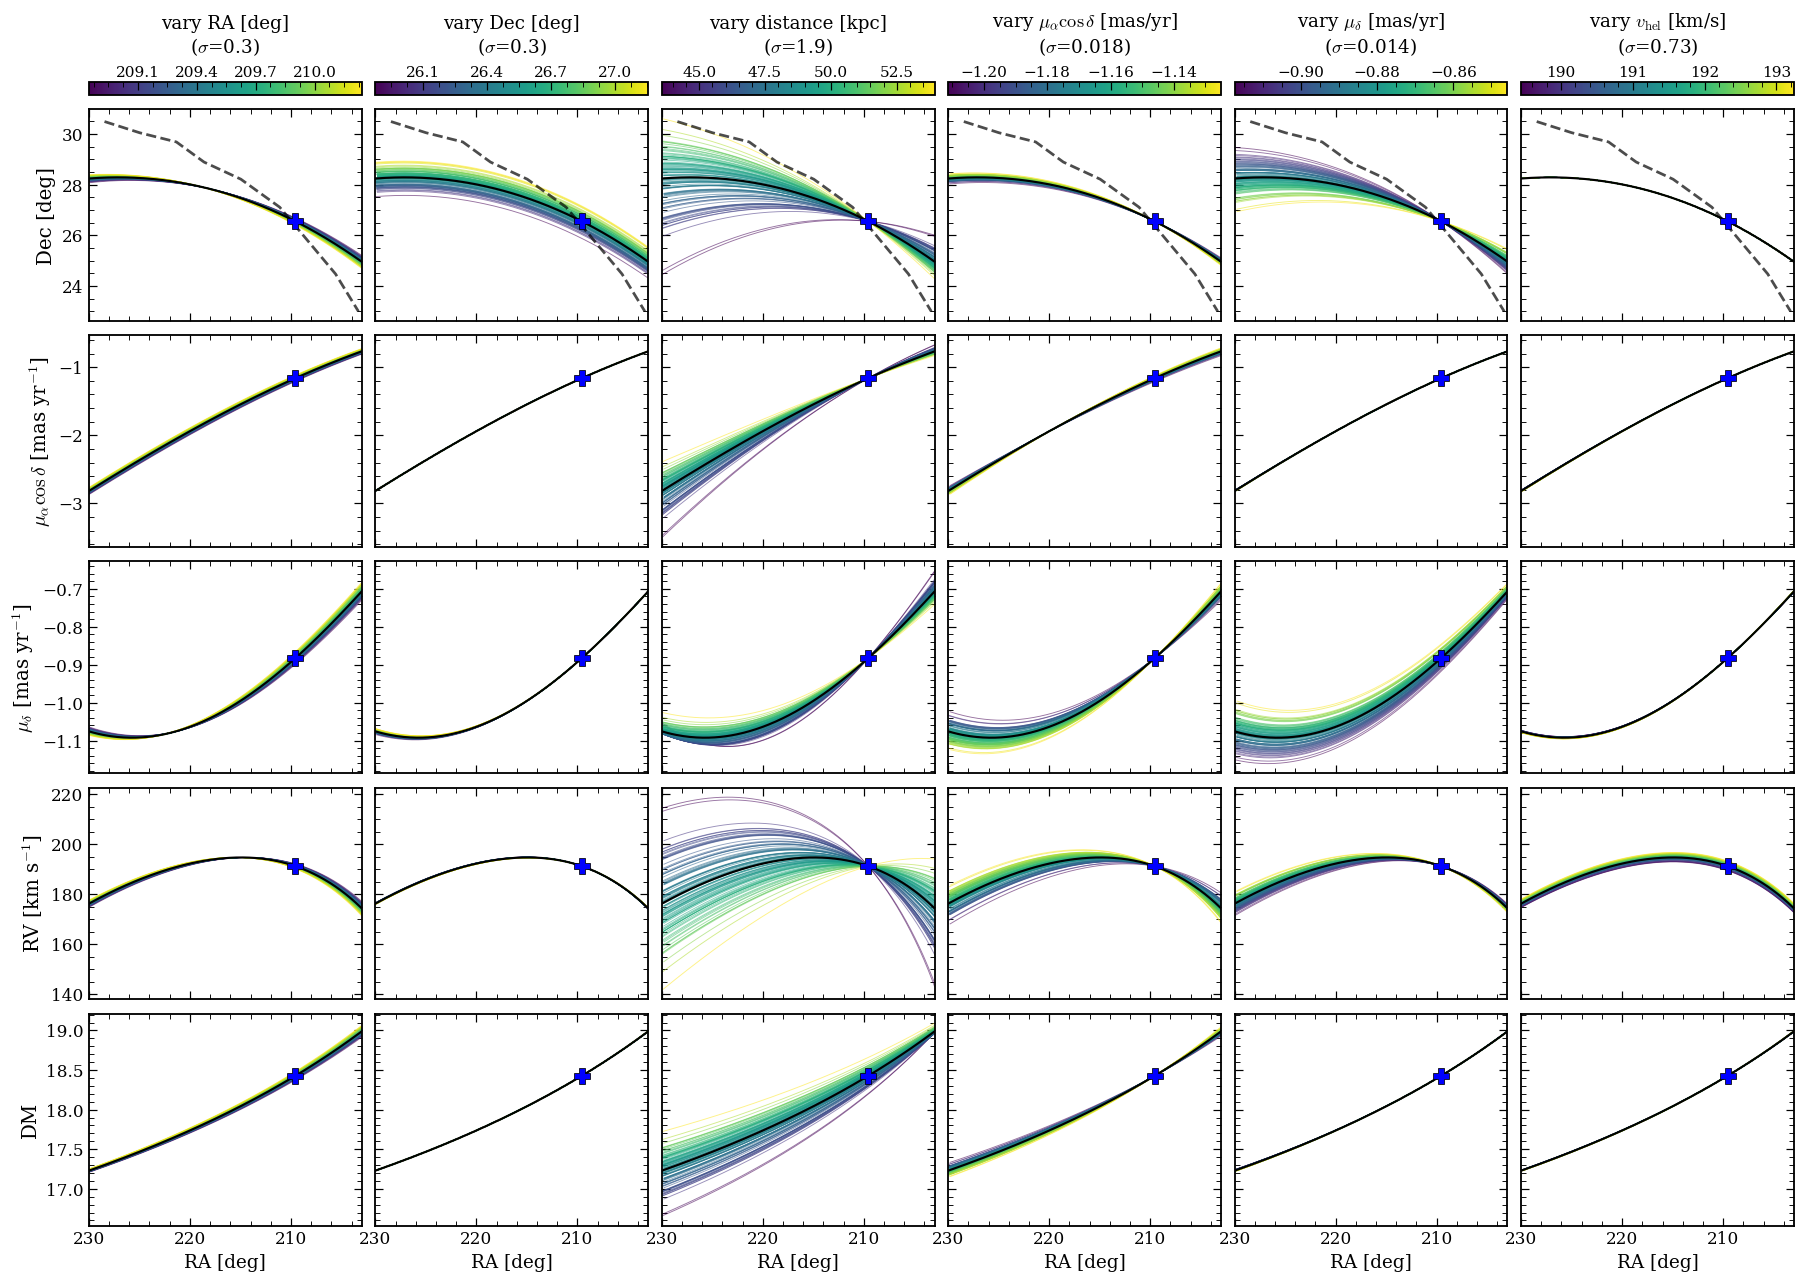


Auto-generated Table 7 (gradient budget) -> /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/paper/boo3_grad_budget.tex

Table 7 contents (matches boo3_grad_budget.tex):
  component  1-sigma in       sigma[dvlos/dxi]  sigma[dvlos/deta]
  ra         0.3                         0.000              0.006
  dec        0.3                         0.015              0.000
  dist       1.9                         1.467              0.204
  pmra       0.018                       0.275              0.074
  pmdec      0.014                       0.140              0.018
  vhel       0.73                        0.000              0.000


In [16]:
PC_TRAJ = OUT_DIR / "orbit_per_component_trajectories.npz"
assert PC_TRAJ.exists(), f"MISSING {PC_TRAJ} — run 01_compute_orbits.py first"
_z = np.load(PC_TRAJ)
COMP_KEYS = [k for k in _z["comp_keys"]]
COMP_LABEL = {"ra": "RA", "dec": "Dec", "dist": "distance",
              "pmra": r"$\mu_\alpha\cos\delta$", "pmdec": r"$\mu_\delta$",
              "vhel": r"$v_{\rm hel}$"}
COMP_IDX = dict(ra=0, dec=1, dist=2, pmra=3, pmdec=4, vhel=5)
COMP_UNIT = {"ra": "deg", "dec": "deg", "dist": "kpc",
             "pmra": "mas/yr", "pmdec": "mas/yr", "vhel": "km/s"}
# Manual colorbar-tick spacing per column.  RA + Dec get a coarser 0.3 step
# so the labels aren't cramped (default 0.2 was too busy at sigma=0.3).
COMP_TICK_STEP = {"ra": 0.3, "dec": 0.3}
# Trajectory key holding the per-realisation value of each varied component
# (vhel is recorded as v_los at present-day).
COMP_TRAJKEY = {"ra": "ra", "dec": "dec", "dist": "dist",
                "pmra": "pmra", "pmdec": "pmdec", "vhel": "vlos"}
errors_6D = _z["errors_6D"].astype(float).copy()
# Override DISPLAYED sigmas to match Table 1 (boo3_table.tex). The trajectory
# data was generated with errors_6D from the npz; the actual orbit spread is
# essentially unchanged (1.8 vs 1.9 kpc is sub-pixel in this figure), but the
# label should quote the same numbers the paper does in Table 1.
# Table 1: RA 0.3, Dec 0.3, D 1.9 kpc, pmra 0.018, pmdec 0.014, vhel 0.73 km/s.
errors_6D = np.array([0.3, 0.3, 1.9, 0.018, 0.014, 0.73])
fid_ra   = _z["fid_ra"]
fid_dec  = _z["fid_dec"]
fid_pma  = _z["fid_pmra"]; fid_pmd = _z["fid_pmdec"]
fid_v    = _z["fid_vlos"]; fid_d   = _z["fid_dist"]
n_step   = len(fid_ra) // 2 + 1   # arrays are 2*N_STEP_PC - 1 long


def _dm(d_kpc):
    return 5.0 * np.log10(d_kpc * 1e3 / 10.0)


# Styx track from Grillmair+09 — overlaid on the Dec row only, Fig 5 style.
STYX_RA, STYX_DEC = np.loadtxt(str(DATA_DIR / "styx.trace"), unpack=True)

# Transposed layout: rows = observable, cols = which 6D was varied.
# Each column's 100 trajectories are colour-coded by the varied parameter
# value (viridis), with a horizontal colorbar at the top of the column.
ROW_DEFS = [
    ("dec",   "Dec [deg]",                                 fid_dec,    lambda y: y),
    ("pmra",  r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]", fid_pma,    lambda y: y),
    ("pmdec", r"$\mu_\delta$ [mas yr$^{-1}$]",            fid_pmd,    lambda y: y),
    ("vlos",  r"RV [km s$^{-1}$]",                         fid_v,      lambda y: y),
    ("dist",  "DM",                                         _dm(fid_d), _dm),
]
NROWS = len(ROW_DEFS); NCOLS = len(COMP_KEYS)

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.ticker import MultipleLocator

fig = plt.figure(figsize=(20, 13.5))
gs  = fig.add_gridspec(NROWS + 1, NCOLS,
                       height_ratios=[0.06] + [1.0]*NROWS,
                       hspace=0.08, wspace=0.05)
cbar_axes = [fig.add_subplot(gs[0, c]) for c in range(NCOLS)]
plot_axes = np.empty((NROWS, NCOLS), dtype=object)
for r in range(NROWS):
    for c in range(NCOLS):
        sharex = plot_axes[0, c] if r > 0 else None
        sharey = plot_axes[r, 0] if c > 0 else None
        plot_axes[r, c] = fig.add_subplot(gs[r+1, c], sharex=sharex, sharey=sharey)
# Hide y-tick labels on every non-leftmost panel and x-tick labels on every
# non-bottom panel — sharex/sharey only links limits, not labels.
for r in range(NROWS):
    for c in range(NCOLS):
        ax = plot_axes[r, c]
        ax.tick_params(axis="both", which="major", labelsize=11)
        if c > 0:
            plt.setp(ax.get_yticklabels(), visible=False)
        if r < NROWS - 1:
            plt.setp(ax.get_xticklabels(), visible=False)

xlim = (230.0, 203.0); xhi, xlo = max(xlim), min(xlim)


def _mask_to_window(ra_arr, y_arr, i0):
    """NaN-out points outside [xlo, xhi] *and* break the line at any RA
    wraparound (consecutive |ΔRA| > 180 deg).  Keeps the present-day
    point so the centre marker still renders."""
    ra = np.asarray(ra_arr, dtype=float).copy()
    y  = np.asarray(y_arr,  dtype=float).copy()
    out_window = (ra < xlo) | (ra > xhi)
    if i0 is not None:
        out_window[i0] = False
    ra[out_window] = np.nan
    y[out_window]  = np.nan
    dra = np.abs(np.diff(ra))
    for k in np.where(dra > 180)[0]:
        ra[k+1] = np.nan; y[k+1] = np.nan
    return ra, y


cmap = plt.cm.viridis
for ci, comp in enumerate(COMP_KEYS):
    ra_arr = _z.get(f"{comp}__ra")
    if ra_arr is None:
        for ri in range(NROWS): plot_axes[ri, ci].axis("off")
        cbar_axes[ci].axis("off"); continue
    arrs = {k: _z[f"{comp}__{k}"] for k in ["ra","dec","pmra","pmdec","vlos","dist"]}
    n_pc = arrs["ra"].shape[0]
    val_per_real = arrs[COMP_TRAJKEY[comp]][:, n_step-1]
    norm = Normalize(vmin=val_per_real.min(), vmax=val_per_real.max())
    order = np.argsort(val_per_real)   # extreme realisations drawn last (on top)

    for ri, (key, ylbl, fid_y, ytransform) in enumerate(ROW_DEFS):
        ax = plot_axes[ri, ci]
        for j in order:
            ra_p, y_p = _mask_to_window(arrs["ra"][j, :], ytransform(arrs[key][j, :]),
                                         i0=n_step-1)
            ax.plot(ra_p, y_p, "-", c=cmap(norm(val_per_real[j])),
                    lw=0.6, alpha=0.55, zorder=2, rasterized=True)
        ra_f, y_f = _mask_to_window(fid_ra, fid_y, i0=n_step-1)
        ax.plot(ra_f, y_f, "-", c="black", lw=1.4, zorder=4, rasterized=True)
        # Styx track from Grillmair+09 — Dec row only, Fig 5 style.
        if key == "dec":
            sm = (STYX_RA >= xlo) & (STYX_RA <= xhi)
            ax.plot(STYX_RA[sm], STYX_DEC[sm], "k--", lw=1.8, alpha=0.7, zorder=6, rasterized=True)
        ax.plot(RA_BOO3, fid_y[n_step-1], "P", c="blue", ms=10,
                mec="black", mew=0.5, zorder=10)
        if ci == 0:
            ax.set_ylabel(ylbl, fontsize=13)
        if ri == NROWS - 1:
            ax.set_xlabel("RA [deg]")
        ax.set_xlim(*xlim)

    # Horizontal colorbar at the top of this column — ticks + label above
    # the colorbar so the bottom edge sits flush against the panels.
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),
                        cax=cbar_axes[ci], orientation="horizontal")
    cbar.ax.tick_params(labelsize=10, pad=2)
    cbar.ax.xaxis.set_ticks_position("top")
    cbar.ax.xaxis.set_label_position("top")
    if comp in COMP_TICK_STEP:
        cbar.ax.xaxis.set_major_locator(MultipleLocator(COMP_TICK_STEP[comp]))
    cbar.set_label(f"vary {COMP_LABEL[comp]} [{COMP_UNIT[comp]}]\n"
                   f"($\\sigma$={errors_6D[COMP_IDX[comp]]:.3g})",
                   fontsize=12, labelpad=8)

fig.savefig(FIG_DIR / "figA4_orbit_per_component.pdf", dpi=200, bbox_inches="tight")
print(f"Saved {FIG_DIR / 'figA4_orbit_per_component.pdf'}")
plt.show()


# ---- Auto-generate Table 7: per-6D-component gradient budget (boo3_grad_budget.tex) ----
# Mirrors the Table-3 / Table-4 writers in cell 8 / cell 12.
_pc = np.load(OUT_DIR / "orbit_gradient_per_component.npz", allow_pickle=True)
_comp_keys = list(_pc["comp_keys"])
_t7_label = {
    "ra":    (r"RA",                          r"$0.3^\circ$"),
    "dec":   (r"Dec",                         r"$0.3^\circ$"),
    "dist":  (r"$D_\odot$",                   f"${float(errors_6D[2]):.1f}$~kpc"),
    "pmra":  (r"$\mu_\alpha\cos\delta$",      r"$" + f"{float(errors_6D[3]):.3f}" + r"$ \pmUnits"),
    "pmdec": (r"$\mu_\delta$",                r"$" + f"{float(errors_6D[4]):.3f}" + r"$ \pmUnits"),
    "vhel":  (r"$v_{\rm hel}$",               r"$" + f"{float(errors_6D[5]):.2f}" + r"$ \vlosUnits"),
}
def _fmt_t7(x):
    if abs(x) < 0.015:
        return r"$\sim 0.0$"
    return f"${x:.2f}$"

_t7_rows = []
for k in _comp_keys:
    gE_arr = np.asarray(_pc[f"gE_{k}"]).ravel()
    gN_arr = np.asarray(_pc[f"gN_{k}"]).ravel()
    sigE = float(gE_arr.std())
    sigN = float(gN_arr.std())
    label, sigma_in = _t7_label.get(k, (k, ""))
    if k == "dist":
        cE = f"$\\mathbf{{{sigE:.2f}}}$"
        cN = f"$\\mathbf{{{sigN:.2f}}}$"
    else:
        cE = _fmt_t7(sigE)
        cN = _fmt_t7(sigN)
    _t7_rows.append(f"{label} & {sigma_in} & {cE} & {cN} \\\\")

_t7_tex = (
    "\\begin{table*}[h]\n"
    "\\centering\n"
    "\\caption{Per-6D-component contribution to the orbit-velocity-gradient "
    "$1\\sigma$ uncertainty, for the McMillan17 + LMC fiducial potential, "
    "with 100 MC realisations per component and the Table~\\ref{tab:params} "
    "1$\\sigma$ on each axis.}\n"
    "\\label{tab:grad_budget}\n"
    "\\begin{tabular}{l c c c}\n"
    "\\hline\\hline\n"
    "6D component & $1\\sigma$ input & "
    "$\\sigma[\\partial v_{\\rm los}/\\partial\\xi]$ & "
    "$\\sigma[\\partial v_{\\rm los}/\\partial\\eta]$ \\\\\n"
    "             &                 & [\\vlosUnits~deg$^{-1}$] & [\\vlosUnits~deg$^{-1}$] \\\\\n"
    "\\hline\n"
    + "\n".join(_t7_rows) + "\n"
    + "\\hline\n\\end{tabular}\n\\end{table*}\n"
)
_t7_tex_path = PROJ / "paper" / "boo3_grad_budget.tex"
_t7_tex_path.write_text(_t7_tex)
print(f"\nAuto-generated Table 7 (gradient budget) -> {_t7_tex_path}")

print("\nTable 7 contents (matches boo3_grad_budget.tex):")
print(f"  {'component':<10s} {'1-sigma in':<14s} {'sigma[dvlos/dxi]':>18s} {'sigma[dvlos/deta]':>18s}")
for k in _comp_keys:
    gE_arr = np.asarray(_pc[f"gE_{k}"]).ravel()
    gN_arr = np.asarray(_pc[f"gN_{k}"]).ravel()
    print(f"  {k:<10s} {str(float(errors_6D[_comp_keys.index(k)])):<14s} "
          f"{gE_arr.std():>18.3f} {gN_arr.std():>18.3f}")
